# RNA to Translation Efficiency (TE) Prediction

**Objective:** Train a MultiTask Lasso model to predict ribosomal protein translation efficiency from non-ribosomal RNA abundance patterns, then apply the model to compound perturbation data to identify translational modulators.

## Table of Contents
1. [Environment Setup](#step-1) - Imports and configuration
2. [Data Paths & Validation](#step-2) - File paths and existence checks
3. [Helper Functions](#step-3) - Utility functions for data processing
4. [Data Loading](#step-4) - Load RNA and TE count matrices
5. [Ribosomal Gene Clustering](#step-5) - Identify RPS/RPL gene groups
6. [Lasso Model per Cluster](#step-6) - Train separate models for RPS and RPL
7. [MultiTask Lasso](#step-7) - Joint model for all ribosomal genes
8. [CIGS Compound Data](#step-8) - Load and process compound perturbation data
9. [Top Compound Visualization](#step-9) - Heatmap of predicted TE changes
10. [Compound Ranking](#step-10) - Score and rank compounds by impact
11. [Baseline: Per-gene Regression](#step-11) - Simple RNA→TE linear models
12. [Baseline: Ridge Regression](#step-12) - Ridge models per ribosomal gene
13. [Compound Diagnostics](#step-13) - Analyze score distributions
14. [Target Difficulty Profile](#step-14) - Which genes are hardest to predict
15. [Accuracy Metrics](#step-15) - Model performance evaluation
16. [Biological Implications](#step-16) - Interpret results and FDR
17. [Perturbation Analysis](#step-17) - Deep dive into compound effects

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=140)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 120)

RANDOM_SEED = 1337  # fixed seed for deterministic splits
N_SPLITS = 5        # using a 5-fold cross validation
USE_PCA = False # for dimensionality reduction

<a id="step-2"></a>
## Step 2: Data Paths & Validation
Define file paths and verify all required data files exist before proceeding.

In [50]:
DATA_DIR = "data"

PATH_RNA_COUNTS = os.path.join(DATA_DIR, "RNA_HEK293T.csv")
PATH_TE_COUNTS = os.path.join(DATA_DIR, "TE_HEK293T.csv")
PATH_COUNTS = os.path.join(DATA_DIR, "MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx")
PATH_METADATA = os.path.join(DATA_DIR, "MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx")

required_files = {
    "RNA counts": PATH_RNA_COUNTS,
    "TE counts": PATH_TE_COUNTS,
    "CIGS counts": PATH_COUNTS,
    "CIGS metadata": PATH_METADATA,
}

missing = [name for name, path in required_files.items() if not os.path.exists(path)]
if missing:
    raise FileNotFoundError(f"Missing required data files: {', '.join(missing)}")

print("Data dir:", DATA_DIR)
for name, path in required_files.items():
    print(f"Using {name}:", path)

print("All required data files found.")


Data dir: data
Using RNA counts: data\RNA_HEK293T.csv
Using TE counts: data\TE_HEK293T.csv
Using CIGS counts: data\MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx
Using CIGS metadata: data\MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx
All required data files found.


<a id="step-3"></a>
## Step 3: Helper Functions
Utility functions for data cleaning, transposition detection, and CLR normalization.

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def drop_index_like(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["Unnamed: 0"], errors="ignore")

def pick_id_col(cols) -> str:
    for c in ["gene", "transcript", "feature_id", "id"]:
        if c in cols: return c
    return cols[0]

def safe_pearsonr(a: np.ndarray, b: np.ndarray) -> float:
    if np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    r = np.corrcoef(a, b)[0,1]
    return float(r) if np.isfinite(r) else float("nan")

def eval_per_gene(y_true: np.ndarray, y_pred: np.ndarray, ids) -> pd.DataFrame:
    rows = []
    for j, gid in enumerate(ids):
        yt = y_true[:, j]; yp = y_pred[:, j]
        r  = safe_pearsonr(yt, yp)
        ss_res = np.sum((yt - yp)**2)
        ss_tot = np.sum((yt - np.mean(yt))**2)
        r2 = float("nan") if ss_tot == 0 else 1.0 - (ss_res/ss_tot)
        mae = mean_absolute_error(yt, yp)
        rmse = mean_squared_error(yt, yp)
        rows.append({"id": gid, "pearson_r": r, "r2": r2, "mae": mae, "rmse": rmse})
    return pd.DataFrame(rows)

def to_gene_symbols(df: pd.DataFrame, id_col: str, tx2gene: pd.DataFrame=None) -> pd.DataFrame:
    if tx2gene is None or not set(["transcript","gene_symbol"]).issubset(tx2gene.columns):
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    if id_col.lower() != "transcript":
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    out = df.merge(tx2gene[["transcript","gene_symbol"]], left_on=id_col, right_on="transcript", how="left")
    out["gene_symbol"] = out["gene_symbol"].fillna(out[id_col].astype(str))
    out = out.drop(columns=["transcript_y"], errors="ignore")
    out = out.rename(columns={"transcript_x":"transcript"})
    return out

def rps_rpl_mask(symbols: pd.Series) -> pd.Series:
    s = symbols.fillna("").str.upper()
    return s.str.startswith("RPS") | s.str.startswith("RPL")

<a id="step-4"></a>
## Step 4: Data Loading
Load RNA and TE count matrices, transpose if needed, and apply CLR normalization.

In [63]:
rna = drop_index_like(pd.read_csv(PATH_RNA_COUNTS))
te  = drop_index_like(pd.read_csv(PATH_TE_COUNTS))

id_col_rna = pick_id_col(rna.columns.tolist())
id_col_te  = pick_id_col(te.columns.tolist())

sample_cols = [c for c in rna.columns if c != id_col_rna and c in te.columns]
rna = rna[[id_col_rna] + sample_cols].copy()
te  = te [[id_col_te ] + sample_cols].copy()

common_ids = sorted(set(rna[id_col_rna]) & set(te[id_col_te]))
rna = rna[rna[id_col_rna].isin(common_ids)].sort_values(id_col_rna).reset_index(drop=True)
te  = te [te [id_col_te ].isin(common_ids)].sort_values(id_col_te ).reset_index(drop=True)

rna = rna.rename(columns={id_col_rna: "feature_id"})
te  = te .rename(columns={id_col_te:  "feature_id"})

print("RNA shape:", rna.shape)
print("TE  shape:", te.shape)
print("Samples:", len(sample_cols))

RNA shape: (8433, 99)
TE  shape: (8433, 99)
Samples: 98


<a id="step-5"></a>
## Step 5: Ribosomal Gene Clustering
Identify and visualize RPS (40S) and RPL (60S) ribosomal protein gene clusters.

In [64]:
tx2gene = None
rna_sym = to_gene_symbols(rna, "feature_id", tx2gene)
te_sym  = to_gene_symbols(te,  "feature_id", tx2gene)

genes = rna["feature_id"].tolist()
gene_symbols = rna_sym["gene_symbol"].tolist()

X = rna[sample_cols].T.values  # RNA
Y = te [sample_cols].T.values  # TE

print("Matrix shapes — X:", X.shape, "Y:", Y.shape)

Matrix shapes — X: (98, 8433) Y: (98, 8433)


<a id="step-6"></a>
## Step 6: Lasso Models per Cluster
Train separate Lasso models for RPS and RPL clusters to identify top RNA predictors.

In [65]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

def cv_predict_vector(X, y, alphas=None, n_splits=5, random_state=1337):
    if alphas is None:
        alphas = np.logspace(-3, 1, 20)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    yhat = np.empty_like(y, dtype=float)
    chosen, nnz = [], []
    for tr, te in kf.split(X):
        lcv = LassoCV(alphas=alphas, cv=5, random_state=random_state, n_jobs=-1, max_iter=10000)
        lcv.fit(X[tr], y[tr])
        yhat[te] = lcv.predict(X[te])
        chosen.append(lcv.alpha_)
        nnz.append(np.count_nonzero(lcv.coef_))
    return yhat, np.array(chosen), np.array(nnz)

# Masks (expects gene_symbols: array-like of gene names)
sym = pd.Series(gene_symbols).str.upper()
rps_mask = sym.str.startswith("RPS").values
rpl_mask = sym.str.startswith("RPL").values

# Cluster targets (mean TE across genes in cluster)
TE_RPS = np.nanmean(Y[:, rps_mask], axis=1)
TE_RPL = np.nanmean(Y[:, rpl_mask], axis=1)

# Run CV prediction
Yhat_RPS, alphas_rps, nnz_rps = cv_predict_vector(X, TE_RPS)
Yhat_RPL, alphas_rpl, nnz_rpl = cv_predict_vector(X, TE_RPL)

# Compact summary
def summarize(y, yhat, name):
    r = np.corrcoef(y, yhat)[0, 1] if (np.std(y) > 0 and np.std(yhat) > 0) else np.nan
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    print(f"{name}: r={r:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

summarize(TE_RPS, Yhat_RPS, "RPS cluster")
summarize(TE_RPL, Yhat_RPL, "RPL cluster")
print("Median alpha (RPS, RPL):", float(np.median(alphas_rps)), float(np.median(alphas_rpl)))
print("Median non-zero features (RPS, RPL):", int(np.median(nnz_rps)), int(np.median(nnz_rpl)))

RPS cluster: r=0.964, MAE=0.167, RMSE=0.240
RPL cluster: r=0.969, MAE=0.192, RMSE=0.268
Median alpha (RPS, RPL): 0.029763514416313176 0.018329807108324356
Median non-zero features (RPS, RPL): 14 29


In [66]:
from sklearn.linear_model import LassoCV

# Fit final Lasso model on full data (no scaling)
def fit_full_lasso(X_data, y, alpha):
    nan_mask = np.isnan(y)
    X_clean = X_data[~nan_mask]
    y_clean = y[~nan_mask]

    if len(y_clean) == 0:
        print("Warning: No non-NaN samples found for this target vector. Cannot fit model.")
        return None, None

    model = LassoCV(alphas=[alpha], cv=min(5, len(y_clean)), random_state=RANDOM_SEED, max_iter=10000).fit(X_clean, y_clean)
    return model, None

# Load and transpose RNA data explicitly for this cell
rna_for_lasso = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
id_col_rna_for_lasso = pick_id_col(rna_for_lasso.columns.tolist())
sample_cols_for_lasso = [c for c in rna_for_lasso.columns if c != id_col_rna_for_lasso]
X_lasso = rna_for_lasso[sample_cols_for_lasso].T.values

# Use median alpha values from cross-validation results
alpha_rps = float(np.nanmedian(alphas_rps))
alpha_rpl = float(np.nanmedian(alphas_rpl))

lasso_rps, scaler_rps = fit_full_lasso(X_lasso, TE_RPS, alpha_rps)
lasso_rpl, scaler_rpl = fit_full_lasso(X_lasso, TE_RPL, alpha_rpl)

# Top features by absolute weight
def top_features(model, k=20):
    if model is None:
        return pd.DataFrame(columns=["gene_id", "gene_symbol", "weight"])
    w = model.coef_
    rna_for_features = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
    id_col_rna_for_features = pick_id_col(rna_for_features.columns.tolist())
    rna_for_features = rna_for_features.rename(columns={id_col_rna_for_features: "feature_id"})
    genes_for_features = rna_for_features["feature_id"].tolist()
    gene_symbols_for_features = [str(g) for g in genes_for_features]

    idx = np.argsort(-np.abs(w))[:k]
    return pd.DataFrame({
        "gene_id": [genes_for_features[i] for i in idx],
        "gene_symbol": [gene_symbols_for_features[i] for i in idx],
        "weight": w[idx]
    })

print("\nTop RNA features for RPS cluster:\n", top_features(lasso_rps).to_string(index=False))
print("\nTop RNA features for RPL cluster:\n", top_features(lasso_rpl).to_string(index=False))


Top RNA features for RPS cluster:
  gene_id gene_symbol    weight
   RPL10       RPL10 -0.471598
    RPL4        RPL4 -0.224940
  EEF1A1      EEF1A1 -0.077805
   FOSL2       FOSL2  0.037908
   CHAC1       CHAC1  0.031155
EPM2AIP1    EPM2AIP1 -0.029779
   HSPB1       HSPB1 -0.023778
    LDAH        LDAH  0.013874
   DECR1       DECR1  0.012914
  RNASEK      RNASEK -0.011497
    NAAA        NAAA  0.011151
   DUSP5       DUSP5  0.010838
   HHLA3       HHLA3 -0.009589
  S100A4      S100A4 -0.004351
  MT-ND5      MT-ND5 -0.000000
 MT-ND4L     MT-ND4L -0.000000
 MT-ATP6     MT-ATP6 -0.000000
 MT-ATP8     MT-ATP8 -0.000000
  MT-CO2      MT-CO2 -0.000000
   VAMP7       VAMP7 -0.000000

Top RNA features for RPL cluster:
 gene_id gene_symbol    weight
  RPL10       RPL10 -0.496531
   RPL4        RPL4 -0.307308
  FOSL2       FOSL2  0.082559
  RPS29       RPS29 -0.075645
  RPL28       RPL28 -0.058885
  CHAC1       CHAC1  0.054376
   MLH1        MLH1 -0.042942
 TPRG1L      TPRG1L  0.034714
  SPOPL

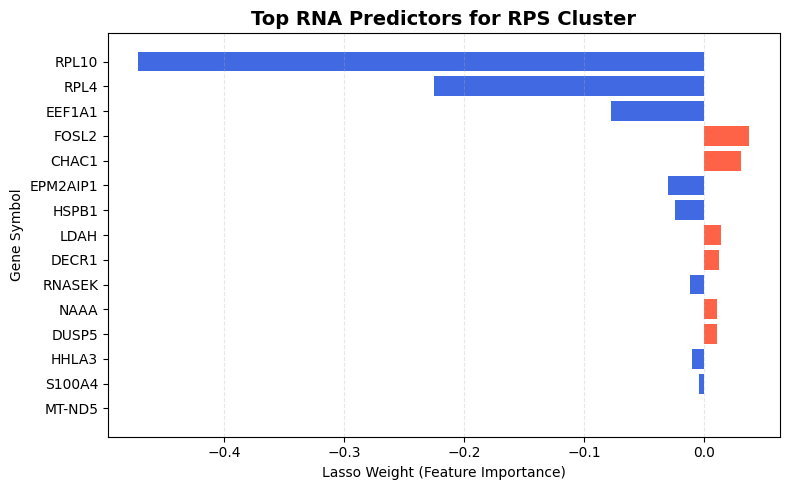

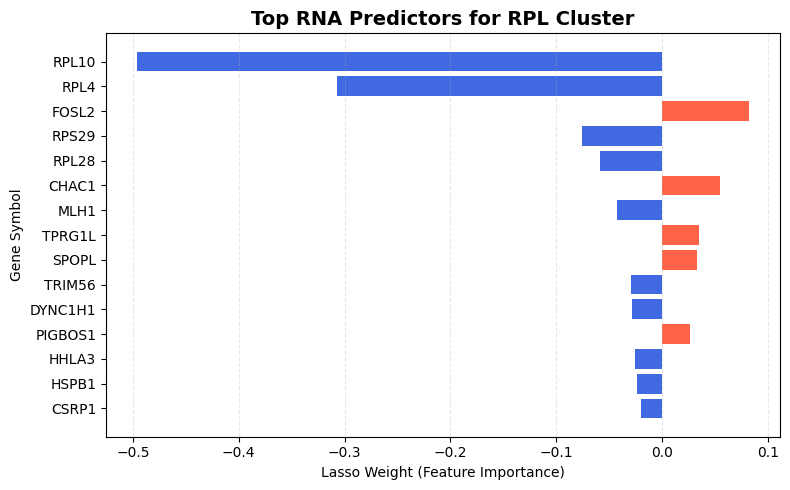

In [67]:
def plot_lasso_weights(df, title, top_k=15):
    """
    Create a horizontal barplot of the top_k most important RNA features.
    Red = positive weight (higher RNA, higher cluster TE)
    Blue = negative weight (higher RNA, lower cluster TE)
    """
    # Sort by absolute weight, take top_k
    df_sorted = df.reindex(df["weight"].abs().sort_values(ascending=False).index)[:top_k]

    plt.figure(figsize=(8, 5))
    colors = df_sorted["weight"].apply(lambda x: "tomato" if x > 0 else "royalblue")

    plt.barh(df_sorted["gene_symbol"], df_sorted["weight"], color=colors)
    plt.gca().invert_yaxis()  # most important feature on top

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Lasso Weight (Feature Importance)")
    plt.ylabel("Gene Symbol")
    plt.grid(alpha=0.3, linestyle="--", axis="x")
    plt.tight_layout()
    plt.show()

top_rps_df = top_features(lasso_rps, k=20)
top_rpl_df = top_features(lasso_rpl, k=20)

plot_lasso_weights(top_rps_df, "Top RNA Predictors for RPS Cluster", top_k=15)
plot_lasso_weights(top_rpl_df, "Top RNA Predictors for RPL Cluster", top_k=15)

<a id="step-7"></a>
## Step 7: MultiTask Lasso for Ribosomal TE
Train a joint model predicting all ribosomal genes simultaneously using non-ribosomal RNA features.

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import MultiTaskLasso, MultiTaskLassoCV
from sklearn.metrics import mean_squared_error

def to_numeric(df): return df.apply(pd.to_numeric, errors="coerce")
def fill_cols(df):  return df.fillna(df.mean(axis=0))
def clr(df):        # rows = samples, cols = genes
    df = df.clip(lower=1e-6)
    gm = np.exp(np.log(df).mean(axis=1))
    return np.log(df.div(gm, axis=0))

rna_raw = pd.read_csv(PATH_RNA_COUNTS)
te_raw  = pd.read_csv(PATH_TE_COUNTS)

id_rna = 'transcript' if 'transcript' in rna_raw.columns else rna_raw.columns[0]
id_te  = 'transcript' if 'transcript' in te_raw.columns  else te_raw.columns[0]
rna_raw = rna_raw.set_index(id_rna)
te_raw  = te_raw.set_index(id_te)

samples = rna_raw.columns.intersection(te_raw.columns)
genes   = rna_raw.index.intersection(te_raw.index)

rna = to_numeric(rna_raw.loc[genes, samples])
te  = to_numeric(te_raw .loc[genes, samples])

# masks 
sym        = pd.Index(genes).str.upper()
is_ribo    = sym.str.startswith('RPS') | sym.str.startswith('RPL')     # Y targets
is_nonribo = ~is_ribo                                                  # X predictors

X_train_all = rna.loc[is_nonribo]   # genes×samples
Y_train_all = te .loc[is_ribo]      # genes×samples

# build matrices 
X_mat = fill_cols(X_train_all).T.values.astype(np.float32)  # samples×features
Y_mat = fill_cols(Y_train_all).T.values.astype(np.float32)  # samples×targets
feature_names = np.array(X_train_all.index)                 # non-RPS/RPL gene symbols
target_names  = np.array(Y_train_all.index)                 # RPS/RPL gene symbols

# train 
USE_CV = False
ALPHA  = 0.01
if USE_CV:
    mtl_model = MultiTaskLassoCV(
        cv=5,
        n_alphas=50,
        max_iter=3000,
        tol=1e-3,
        random_state=1337,
        n_jobs=-1
    ).fit(X_mat, Y_mat)
    mtl_alpha = float(mtl_model.alpha_)
else:
    mtl_model = MultiTaskLasso(alpha=ALPHA, max_iter=3000, tol=1e-3).fit(X_mat, Y_mat)
    mtl_alpha = ALPHA

rmse = np.sqrt(mean_squared_error(Y_mat, mtl_model.predict(X_mat)))
print(f"Train RMSE: {rmse:.3f} | alpha*: {mtl_alpha}")
print(f"Non-ribosomal predictors used: {len(feature_names)}")


Train RMSE: 10.636 | alpha*: 0.01
Non-ribosomal predictors used: 8346



===== MultiTask Lasso Model Summary =====
Targets (RPS/RPL genes): 87
Predictor features (non-ribosomal genes): 8346
Sparsity (fraction of zeros): 0.0000
Median non-zero predictors per ribosomal gene: 8346.0
Predictors used in at least 5 ribosomal genes: 8346

===== Per-Target RMSE (first few) =====
RPL22: RMSE=0.222
RPL11: RMSE=0.324
RPS6KA1: RMSE=0.347
RPS8: RMSE=0.632
RPL5: RMSE=0.869
RPS27: RMSE=1.180
RPS6KC1: RMSE=1.927
RPS7: RMSE=1.825
RPS27A: RMSE=2.126
RPL31: RMSE=2.376

Mean per-target RMSE: 9.299
Median per-target RMSE: 9.581

===== Top 25 MultiTask Predictors (by mean |coef|) =====


,gene,mean_abs_coef,nonzero_count
0,NOC2L,151.195053,87
1,INTS11,105.451981,87
2,DVL1,93.990334,87
3,AURKAIP1,64.768967,87
4,CDK11B,39.558094,87
5,AGRN,36.456337,87
6,PUSL1,31.827328,87
7,MIB2,30.463980,87
8,CCNL2,26.818462,87
9,SLC35E2B,23.736095,87


C:\Users\lintu\AppData\Local\Temp\ipykernel_31588\3035761858.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_summary["mean_abs_coef"],


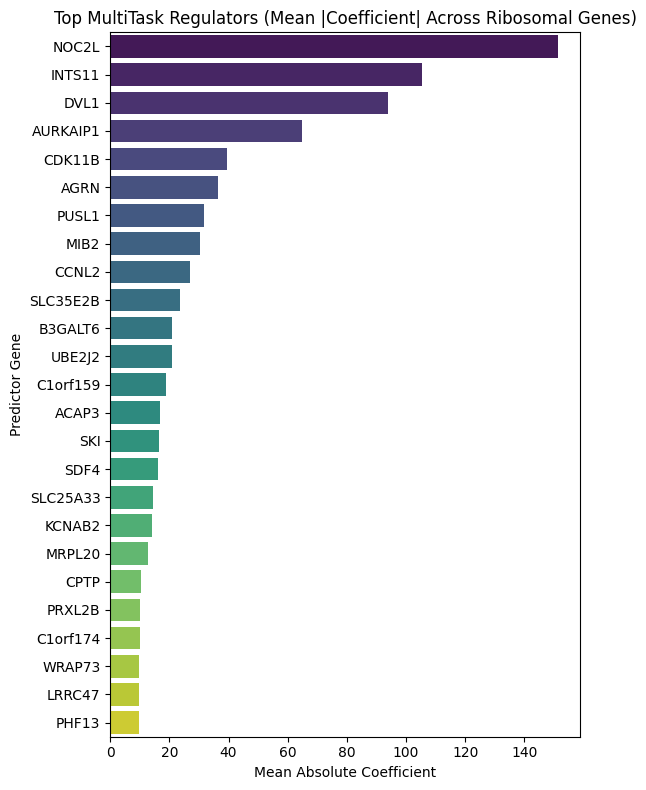

In [70]:
coef_matrix = mtl_model.coef_          # shape: [n_targets, n_features]
n_targets, n_features = coef_matrix.shape

nonzero_per_target = np.sum(coef_matrix != 0, axis=1)   # per RPS/RPL gene
nonzero_per_feature = np.sum(coef_matrix != 0, axis=0)  # per predictor gene

print("\n===== MultiTask Lasso Model Summary =====")
print(f"Targets (RPS/RPL genes): {n_targets}")
print(f"Predictor features (non-ribosomal genes): {n_features}")
print(f"Sparsity (fraction of zeros): {np.mean(coef_matrix==0):.4f}")

print(f"Median non-zero predictors per ribosomal gene: {np.median(nonzero_per_target)}")
print(f"Predictors used in at least 5 ribosomal genes: {(nonzero_per_feature >= 5).sum()}")

# Per-target prediction errors
Y_pred = mtl_model.predict(X_mat)

per_target_rmse = np.sqrt(np.mean((Y_mat - Y_pred)**2, axis=0))

print("\n===== Per-Target RMSE (first few) =====")
for name, err in zip(target_names[:10], per_target_rmse[:10]):
    print(f"{name}: RMSE={err:.3f}")

print(f"\nMean per-target RMSE: {per_target_rmse.mean():.3f}")
print(f"Median per-target RMSE: {np.median(per_target_rmse):.3f}")

# Feature  summary across all ribosomal genes
mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top_idx = np.argsort(mean_abs_coef)[::-1][:25]

feature_summary = pd.DataFrame({
    "gene": feature_names[top_idx],
    "mean_abs_coef": mean_abs_coef[top_idx],
    "nonzero_count": nonzero_per_feature[top_idx]
})

print("\n===== Top 25 MultiTask Predictors (by mean |coef|) =====")
display(feature_summary)

# Plot of top multi-target regulators
plt.figure(figsize=(6, 8))
sns.barplot(x=feature_summary["mean_abs_coef"],
            y=feature_summary["gene"], orient="h", palette="viridis")
plt.title("Top MultiTask Regulators (Mean |Coefficient| Across Ribosomal Genes)")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Predictor Gene")
plt.tight_layout()
plt.show()

<a id="step-8"></a>
## Step 8: CIGS Compound Perturbation Data
Load compound perturbation data, align to training features, and predict TE changes for 11K+ compounds.

In [72]:
import zipfile
import xml.etree.ElementTree as ET

XLSX_MAIN_NS = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
XLSX_REL_NS = "http://schemas.openxmlformats.org/officeDocument/2006/relationships"

def _col_ref_to_index(ref: str) -> int:
    letters = "".join(ch for ch in ref if ch.isalpha()) or "A"
    idx = 0
    for ch in letters.upper():
        idx = idx * 26 + (ord(ch) - 64)
    return idx - 1

def _load_shared_strings(zf: zipfile.ZipFile) -> list[str]:
    try:
        root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
    except KeyError:
        return []
    strings = []
    for si in root.findall(f".//{{{XLSX_MAIN_NS}}}si"):
        parts = [t.text or "" for t in si.findall(f".//{{{XLSX_MAIN_NS}}}t")]
        strings.append("".join(parts))
    return strings

def _sheet_targets(zf: zipfile.ZipFile):
    workbook = ET.fromstring(zf.read("xl/workbook.xml"))
    rels_root = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))
    rid_to_target = {rel.attrib["Id"]: rel.attrib.get("Target", "") for rel in rels_root}
    sheets = []
    for sheet in workbook.findall(f".//{{{XLSX_MAIN_NS}}}sheet"):
        name = sheet.attrib.get("name")
        rid = sheet.attrib.get(f"{{{XLSX_REL_NS}}}id")
        target = rid_to_target.get(rid, "")
        if target and not target.startswith("xl/"):
            target = f"xl/{target}"
        sheets.append((name, target))
    return sheets

def _sheet_rows(zf: zipfile.ZipFile, target: str, shared_strings):
    """Stream sheet rows to avoid overflowing ET.fromstring on large worksheets."""
    row_dicts = []
    max_col = -1
    row_tag = f"{{{XLSX_MAIN_NS}}}row"
    cell_tag = f"{{{XLSX_MAIN_NS}}}c"
    value_tag = f"{{{XLSX_MAIN_NS}}}v"
    text_tag = f"{{{XLSX_MAIN_NS}}}t"
    with zf.open(target) as handle:
        context = ET.iterparse(handle, events=("start", "end"))
        current_row = None
        for event, elem in context:
            if event == "start" and elem.tag == row_tag:
                current_row = {}
            elif event == "end" and elem.tag == cell_tag and current_row is not None:
                ref = elem.attrib.get("r", "")
                col_idx = _col_ref_to_index(ref)
                cell_type = elem.attrib.get("t")
                value = ""
                if cell_type == "inlineStr":
                    value = "".join(t.text or "" for t in elem.findall(f".//{text_tag}"))
                else:
                    v = elem.find(value_tag)
                    if v is not None:
                        value = v.text or ""
                        if cell_type == "s":
                            try:
                                value = shared_strings[int(value)]
                            except (ValueError, IndexError):
                                value = ""
                current_row[col_idx] = value
                if col_idx > max_col:
                    max_col = col_idx
                elem.clear()
            elif event == "end" and elem.tag == row_tag:
                if current_row:
                    row_dicts.append(current_row)
                current_row = None
                elem.clear()
    matrix = []
    for cells in row_dicts:
        row_values = ["" for _ in range(max_col + 1)]
        for idx, val in cells.items():
            row_values[idx] = val
        matrix.append(row_values)
    return matrix

def read_xlsx_simple(fp, sheet=None, skiprows=0):
    with zipfile.ZipFile(fp) as zf:
        sheets = _sheet_targets(zf)
        if not sheets:
            raise ValueError(f"No worksheets found in {fp}.")
        if sheet is None:
            target = sheets[0][1]
        elif isinstance(sheet, int):
            target = sheets[sheet][1]
        else:
            matches = [t for name, t in sheets if name == sheet]
            if not matches:
                raise ValueError(f"Sheet '{sheet}' not found in {fp}.")
            target = matches[0]
        shared_strings = _load_shared_strings(zf)
        rows = _sheet_rows(zf, target, shared_strings)
    rows = [row for row in rows if any(cell != "" for cell in row)]
    if skiprows:
        rows = rows[skiprows:]
    if not rows:
        return pd.DataFrame()
    header = rows[0]
    data = rows[1:]
    return pd.DataFrame(data, columns=header)

def pick_metadata_field(columns, priority_exact, keywords, label):
    normalized = {str(col).strip().lower(): col for col in columns}
    for target in priority_exact:
        if target in normalized:
            return normalized[target]
    for col in columns:
        low = str(col).strip().lower()
        if any(key in low for key in keywords):
            return col
    raise ValueError(f"Unable to identify {label} column. Columns seen: {list(columns)}")

def _maybe_reheader_counts(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if not df.empty and len(df) >= 4:
        first_cell = str(df.iloc[0, 0]).strip().lower()
        if first_cell.startswith("note"):
            # Row 0: Note disclaimer, Row 1: blank, Row 2: Sample_id header, Row 3+: data
            # But gene symbols are in row 2 (columns B onward)
            new_header = df.iloc[2].tolist()
            df = df.iloc[3:].reset_index(drop=True)
            df.columns = new_header
    df = df.rename(columns=lambda c: str(c).strip())
    return df

def _counts_to_samples(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    if df.empty:
        return df, "unknown"
    df = df[df[df.columns[0]].astype(str).str.strip().ne("")]
    df = df.set_index(df.columns[0])
    numeric = df.apply(pd.to_numeric, errors="coerce")
    numeric.index.name = str(numeric.index.name) or str(df.index.name) or str(df.columns[0])
    return numeric, "sample_rows"

def _row_to_letter(value: str) -> str:
    value = str(value).strip()
    if not value:
        return ""
    if value.isdigit():
        num = int(float(value))
        if 1 <= num <= 26:
            return chr(ord("A") + num - 1)
    if len(value) == 1 and value.isalpha():
        return value.upper()
    return value.upper()

def _format_column(value: str) -> str:
    value = str(value).strip()
    if not value:
        return ""
    try:
        return f"{int(float(value)):02d}"
    except ValueError:
        digits = "".join(ch for ch in value if ch.isdigit())
        return digits.zfill(2) if digits else value

def _build_plate_well(meta_df: pd.DataFrame) -> pd.Series:
    required = {"sample_plate", "sample_row", "sample_column"}
    if not required.issubset(meta_df.columns):
        return pd.Series(["" for _ in range(len(meta_df))], index=meta_df.index)
    plates = meta_df["sample_plate"].astype(str).str.strip()
    rows = meta_df["sample_row"].apply(_row_to_letter)
    cols = meta_df["sample_column"].apply(_format_column)
    combos = plates + ":" + rows + cols
    mask = plates.ne("") & rows.ne("") & cols.ne("")
    return combos.where(mask, "")

def _align_metadata_to_counts(meta_df: pd.DataFrame, counts_index: pd.Index, sample_col: str):
    meta_df = meta_df.copy()
    candidate_columns: list[tuple[str, str]] = []
    plate_well = _build_plate_well(meta_df)
    if plate_well.str.len().gt(0).any():
        meta_df["_plate_well_key"] = plate_well
        candidate_columns.append(("_plate_well_key", "plate:well coordinate"))
    candidate_columns.append((sample_col, sample_col))
    for col, label in candidate_columns:
        if col not in meta_df.columns:
            continue
        series = meta_df[col].astype(str).str.strip()
        series = series.replace({"nan": "", "None": ""})
        series = series[series.ne("")]
        if series.empty:
            continue
        ordered = counts_index[counts_index.isin(series)]
        if len(ordered) == 0:
            continue
        keyed = meta_df.loc[series.index].copy()
        keyed["_match_key"] = series
        keyed = keyed[keyed["_match_key"].ne("")]
        keyed = keyed.drop_duplicates("_match_key", keep="first").set_index("_match_key")
        missing = ordered.difference(keyed.index)
        if len(missing):
            ordered = ordered.difference(missing)
        if len(ordered) == 0:
            continue
        keyed = keyed.loc[ordered]
        return keyed, ordered, label
    raise ValueError("No overlapping samples between CIGS counts and metadata after cleaning. Check column heuristics.")

print("Loading CIGS compound perturbation data...")
print(f"  Counts file: {PATH_COUNTS}")
print(f"  Metadata file: {PATH_METADATA}")

counts_df = read_xlsx_simple(PATH_COUNTS, skiprows=1)  # Skip the Note row
counts_df = counts_df.rename(columns=lambda c: str(c).strip())
counts_matrix, orientation = _counts_to_samples(counts_df)
print(f"  Counts table interpreted as {orientation.replace('_', ' ')}")

meta_df = read_xlsx_simple(PATH_METADATA, skiprows=1)

# Transpose/clean counts 
cigs_counts = counts_matrix
if cigs_counts.index.name is None:
    cigs_counts.index.name = counts_df.columns[0]
print(f"  Raw CIGS shape: {cigs_counts.shape} (samples x genes)")

# Filter metadata: HEK293T, 24h treatment, valid dose
meta_df = meta_df.rename(columns=lambda c: str(c).strip())
meta_df = meta_df[meta_df['cell_id'].astype(str).str.contains('293T', case=False, na=False)]
meta_df = meta_df[meta_df['pert_itime'].astype(str).str.contains('24', na=False)]
meta_df = meta_df[~meta_df['pert_idose'].astype(str).str.contains('-666', na=False)]

sample_col = pick_metadata_field(
    meta_df.columns,
    priority_exact=["sample", "sample_id", "sampleid", "sample_name", "sampleid_plate", "sampleidbarcode"],
    keywords=["sample"],
    label="sample identifier"
 )
compound_col = pick_metadata_field(
    meta_df.columns,
    priority_exact=["treatment", "compound", "pert_iname", "pertname", "pert_name"],
    keywords=["treat", "compound", "pert", "drug"],
    label="compound name"
 )

meta_df[sample_col] = meta_df[sample_col].astype(str).str.strip()
meta_df[compound_col] = meta_df[compound_col].astype(str).str.strip()
meta_df = meta_df[meta_df[sample_col].ne("")]
meta_df = meta_df[meta_df[compound_col].ne("")]
meta_df = meta_df[~meta_df[sample_col].str.contains('-666', na=False)]
meta_df = meta_df[~meta_df[compound_col].str.contains('-666', na=False)]

# Align metadata IDs to sample IDs present in counts
meta_aligned, shared_samples, match_label = _align_metadata_to_counts(meta_df, cigs_counts.index.astype(str), sample_col)
print(f"  Matched metadata using {match_label} (n={len(shared_samples)})")

# Restrict to shared samples and aggregate per compound
cigs_counts = cigs_counts.loc[shared_samples]
meta_for_counts = meta_aligned.loc[shared_samples]
cigs_counts["compound"] = meta_for_counts[compound_col].values
cigs_counts = cigs_counts.groupby("compound").mean()
print(f"  After filtering and aggregation: {cigs_counts.shape[0]} compounds")

# Apply CLR normalization (same as training data)
cigs_clr = clr(cigs_counts)

# Find common features with training set
common_features = np.intersect1d(feature_names.astype(str), cigs_clr.columns.astype(str))
print(f"  Common features with training: {len(common_features)} genes")
if len(common_features) == 0:
    print(f"  DEBUG: feature_names[:10] = {feature_names[:10]}")
    print(f"  DEBUG: cigs_clr.columns[:10] = {list(cigs_clr.columns[:10])}")
    raise ValueError("No overlapping features between training and CIGS data!")

ordered_features = feature_names.astype(str)
cigs_aligned = cigs_clr.reindex(columns=ordered_features, fill_value=0.0)

# Build prediction matrix (compounds x ordered training features)
X_drug = cigs_aligned.values.astype(np.float32)

print("\nPredicting translational effects...")
pred_TE = mtl_model.predict(X_drug)
pred_TE = pd.DataFrame(pred_TE, index=cigs_clr.index, columns=target_names)
print(f"  Predicted TE matrix: {pred_TE.shape} (compounds x ribosomal genes)")

print("\nRanking compounds by translational impact...")
mean_effect = pred_TE.mean(axis=1)
l2_mag = np.sqrt((pred_TE**2).sum(axis=1))

ranked = pd.DataFrame({
    "mean_effect": mean_effect,
    "l2_magnitude": l2_mag
}).sort_values("l2_magnitude", ascending=False)

print("\nTop 10 compounds by translational impact:")
print(ranked.head(10).to_string())
print(f"\nTotal compounds analyzed: {len(ranked)}")
print(f"Ribosomal genes predicted: {len(target_names)}")
print(f"Non-ribosomal predictors used: {len(feature_names)}")

Loading CIGS compound perturbation data...
  Counts file: data\MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx
  Metadata file: data\MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx
  Counts table interpreted as sample rows
  Counts table interpreted as sample rows
  Raw CIGS shape: (40778, 3407) (samples x genes)
  Raw CIGS shape: (40778, 3407) (samples x genes)
  Matched metadata using plate:well coordinate (n=35424)
  Matched metadata using plate:well coordinate (n=35424)
  After filtering and aggregation: 11358 compounds
  After filtering and aggregation: 11358 compounds
  Common features with training: 1856 genes
  Common features with training: 1856 genes

Predicting translational effects...
  Predicted TE matrix: (11358, 87) (compounds x ribosomal genes)

Ranking compounds by translational impact...

Top 10 compounds by translational impact:
            mean_effect  l2_magnitude
compound                             
HY_13689    1286.636597  13739.764648
HY_15681    1287.56640

<a id="step-9"></a>
## Step 9: Top Compound Visualization
Heatmap showing predicted TE perturbations for the highest-impact compounds.

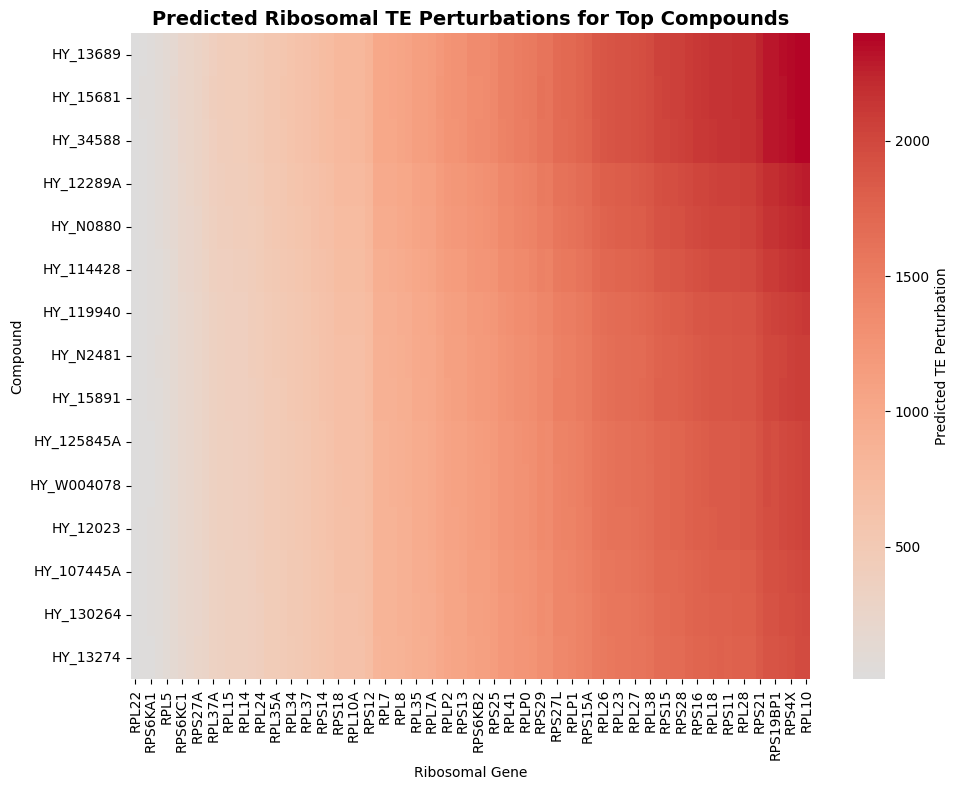

In [74]:
if 'pred_TE' not in globals() or pred_TE is None:
    raise RuntimeError("Compound projections are missing; rerun the CIGS projection cell first.")
if 'ranked' not in globals() or ranked is None:
    raise RuntimeError("Compound rankings are missing; rerun the CIGS projection cell first.")

def plot_heatmap_top_compounds(pred_TE_df, ranked_df, top_k=15):
    """Create a heatmap of predicted TE for the top_k compounds across all target genes."""
    top_compounds = ranked_df.head(top_k).index.tolist()
    heatmap_data = pred_TE_df.loc[top_compounds]

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Predicted TE Perturbation'})
    plt.title("Predicted Ribosomal TE Perturbations for Top Compounds", fontsize=14, weight="bold")
    plt.xlabel("Ribosomal Gene")
    plt.ylabel("Compound")
    plt.tight_layout()
    plt.show()

plot_heatmap_top_compounds(pred_TE, ranked, top_k=15)

<a id="step-10"></a>
## Step 10: Compound Ranking
Combine mean effect and magnitude into a single score to prioritize compounds.

In [75]:
if 'pred_TE' not in globals() or pred_TE is None:
    raise RuntimeError("Compound projections not available yet. Run the CIGS projection cell first.")

mean_effect = pred_TE.mean(axis=1)
l2_mag = np.linalg.norm(pred_TE.values, axis=1)

drug_summary = pd.DataFrame({
    "mean_effect": mean_effect,
    "l2_magnitude": l2_mag
})

drug_summary["z_mean"] = (drug_summary["mean_effect"] - drug_summary["mean_effect"].mean()) / drug_summary["mean_effect"].std()
drug_summary["z_l2"]   = (drug_summary["l2_magnitude"] - drug_summary["l2_magnitude"].mean()) / drug_summary["l2_magnitude"].std()

drug_summary["combined_score"] = drug_summary["z_mean"].abs() + drug_summary["z_l2"]

top_drugs = drug_summary.sort_values("combined_score", ascending=False).head(10)
top_drugs

,mean_effect,l2_magnitude,z_mean,z_l2,combined_score
compound,,,,,
HY_15681,1287.566406,13735.587891,6.219105,6.332991,12.552096
HY_13689,1286.636597,13739.764648,6.211488,6.336259,12.547748
HY_34588,1280.453003,13672.159180,6.160831,6.283359,12.444190
HY_12289A,1227.137329,13089.469727,5.724061,5.827409,11.551471
HY_N0880,1207.151001,12877.758789,5.560331,5.661747,11.222078
HY_114428,1172.134766,12518.290039,5.273473,5.380466,10.653938
HY_119940,1133.846313,12105.293945,4.959808,5.057300,10.017108
HY_N2481,1121.230103,11961.862305,4.856454,4.945066,9.801520
HY_15891,1119.505615,11955.422852,4.842327,4.940027,9.782354


<a id="step-11"></a>
## Step 11: Baseline - Per-Gene Linear Regression
Simple linear models predicting each gene's TE from its own RNA abundance.

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_list = []
rmse_list = []

for g in te.index:
    y = te.loc[g].values
    X = rna.loc[g].values.reshape(-1, 1)
    lr_model = LinearRegression().fit(X, y)
    y_pred = lr_model.predict(X)
    r2_list.append(r2_score(y, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y, y_pred)))

print("Median R²:", np.median(r2_list))
print("Median RMSE:", np.median(rmse_list))


Median R²: 0.9999958886291498
Median RMSE: 0.7253414977512251


<a id="step-12"></a>
## Step 12: Baseline - Ridge Regression
Ridge models fitted independently for each ribosomal gene as a stronger baseline.

In [77]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

ridge_alphas = np.logspace(-3, 3, 25)
ridge_models = {}
ridge_r2_train = []
ridge_rmse_train = []

for idx, gene in enumerate(target_names):
    y_target = Y_mat[:, idx]
    ridge = RidgeCV(alphas=ridge_alphas, cv=min(5, len(y_target)), scoring="neg_mean_squared_error").fit(X_mat, y_target)
    ridge_models[gene] = ridge
    y_fit = ridge.predict(X_mat)
    ridge_r2_train.append(r2_score(y_target, y_fit))
    ridge_rmse_train.append(np.sqrt(mean_squared_error(y_target, y_fit)))

print(f"Fitted ridge models for {len(ridge_models)} targets.")
print(f"Median train R²: {np.median(ridge_r2_train):.3f}")
print(f"Median train RMSE: {np.median(ridge_rmse_train):.3f}")

c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24644e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-pac

Fitted ridge models for 87 targets.
Median train R²: 1.000
Median train RMSE: 0.657


c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.31362e-11): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-pac

In [78]:
from sklearn.metrics import mean_squared_error, r2_score

ridge_r2 = []
ridge_rmse = []

if 'ridge_models' not in globals():
    print("Skipping ridge summary; ridge_models is not defined in this session.")
else:
    for gene, model in ridge_models.items():
        y_true = Y_mat[:, target_names.tolist().index(gene)]
        y_pred = model.predict(X_mat)
        ridge_r2.append(r2_score(y_true, y_pred))
        ridge_rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    print("Ridge Mean R²:", np.mean(ridge_r2))
    print("Ridge Mean RMSE:", np.mean(ridge_rmse))


Ridge Mean R²: 0.9999416066312242
Ridge Mean RMSE: 0.5943281917950746


<a id="step-13"></a>
## Step 13: Compound Score Diagnostics
Visualize directional vs. magnitude components and identify broad-spectrum vs. specific modulators.

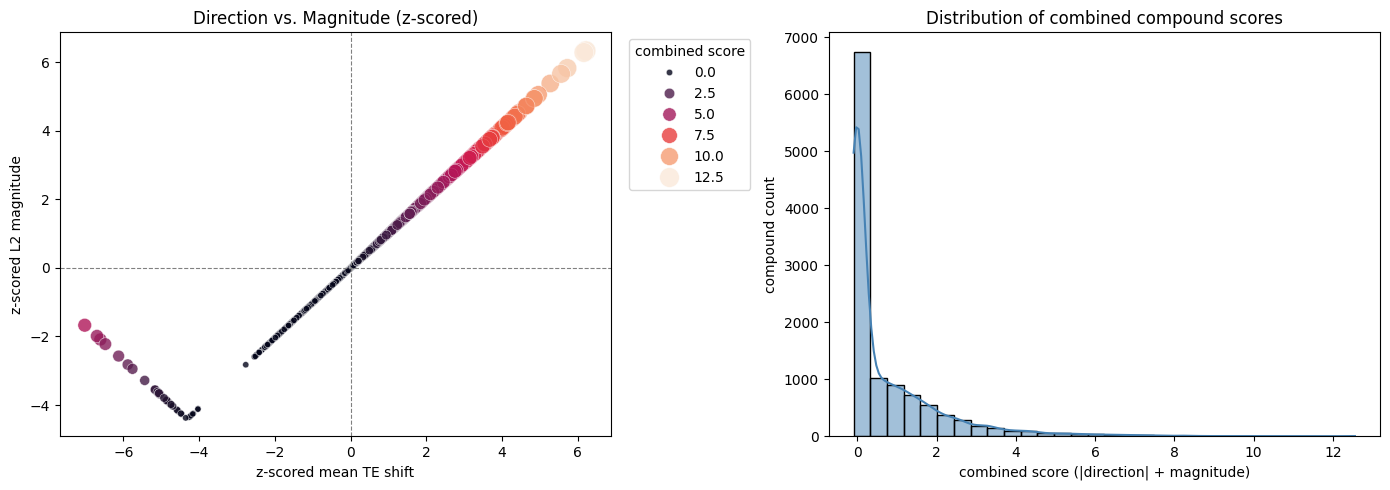

Top 10 combined-score compounds:


,z_mean,z_l2,combined_score
compound,,,
HY_15681,6.219105,6.332991,12.552096
HY_13689,6.211488,6.336259,12.547748
HY_34588,6.160831,6.283359,12.444190
HY_12289A,5.724061,5.827409,11.551471
HY_N0880,5.560331,5.661747,11.222078
HY_114428,5.273473,5.380466,10.653938
HY_119940,4.959808,5.057300,10.017108
HY_N2481,4.856454,4.945066,9.801520
HY_15891,4.842327,4.940027,9.782354


Compounds dominated by directional shifts (|z_mean| > z_l2): 7398
Broad-spectrum modulators (z_l2 >= |z_mean|): 3960


In [79]:
if 'drug_summary' not in globals():
    raise RuntimeError("Compound rankings missing; rerun Step 10 before running diagnostics.")

annotated = drug_summary.copy()
annotated = annotated.assign(compound=annotated.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=annotated,
    x='z_mean',
    y='z_l2',
    hue='combined_score',
    size='combined_score',
    palette='rocket',
    sizes=(20, 200),
    alpha=0.8,
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Direction vs. Magnitude (z-scored)')
axes[0].set_xlabel('z-scored mean TE shift')
axes[0].set_ylabel('z-scored L2 magnitude')
axes[0].legend(title='combined score', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.histplot(
    annotated['combined_score'],
    bins=30,
    color='steelblue',
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Distribution of combined compound scores')
axes[1].set_xlabel('combined score (|direction| + magnitude)')
axes[1].set_ylabel('compound count')

plt.tight_layout()
plt.show()

extreme_hits = annotated.sort_values('combined_score', ascending=False).head(10)[
    ['z_mean', 'z_l2', 'combined_score']
]
print("Top 10 combined-score compounds:")
display(extreme_hits)

directional_bias = annotated.loc[annotated['z_mean'].abs() > annotated['z_l2'], 'compound']
print(f"Compounds dominated by directional shifts (|z_mean| > z_l2): {len(directional_bias)}")
print(f"Broad-spectrum modulators (z_l2 >= |z_mean|): {len(annotated) - len(directional_bias)}")

<a id="step-14"></a>
## Step 14: Ribosomal Target Difficulty Profile
Identify which ribosomal genes are easiest/hardest to predict based on RMSE.

C:\Users\lintu\AppData\Local\Temp\ipykernel_31588\62384606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hardest, x='rmse', y='target', palette='magma')


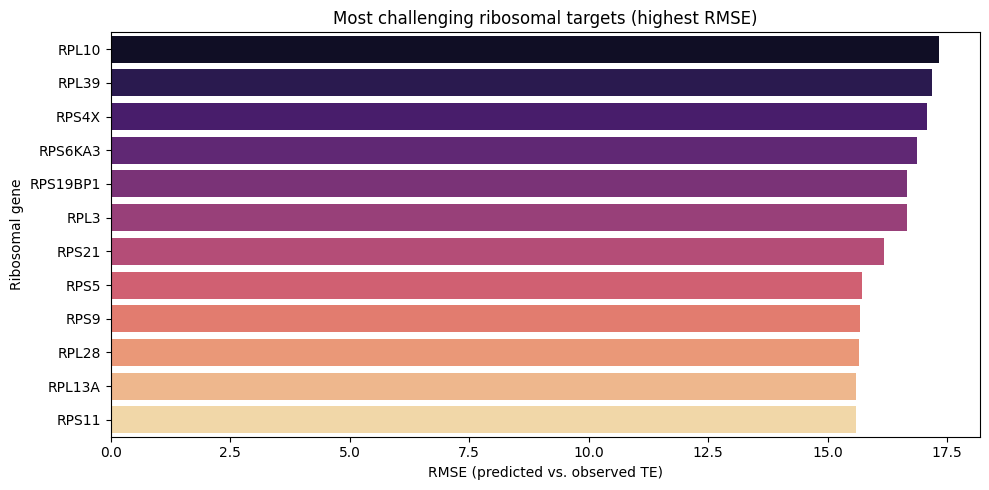

C:\Users\lintu\AppData\Local\Temp\ipykernel_31588\62384606.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=easist, x='rmse', y='target', palette='crest')


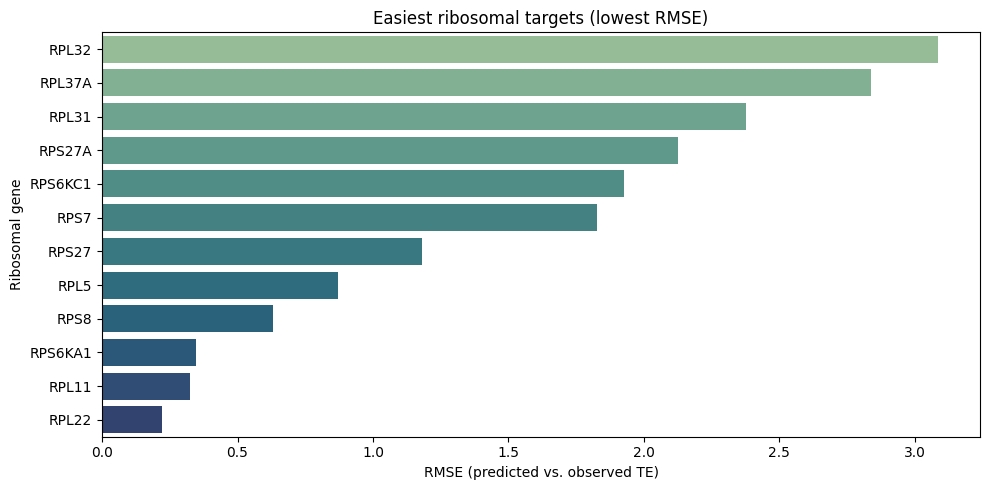

Hardest genes summary:


,target,rmse,nonzero_predictors
0,RPL10,17.324581,8346
1,RPL39,17.181627,8346
2,RPS4X,17.075880,8346
3,RPS6KA3,16.876333,8346
4,RPS19BP1,16.669300,8346
5,RPL3,16.659359,8346
6,RPS21,16.192329,8346
7,RPS5,15.731182,8346
8,RPS9,15.670952,8346
9,RPL28,15.665568,8346


Easiest genes summary:


,target,rmse,nonzero_predictors
0,RPL32,3.085905,8346
1,RPL37A,2.837773,8346
2,RPL31,2.376180,8346
3,RPS27A,2.125827,8346
4,RPS6KC1,1.927084,8346
5,RPS7,1.825385,8346
6,RPS27,1.180043,8346
7,RPL5,0.869168,8346
8,RPS8,0.631703,8346
9,RPS6KA1,0.346750,8346


Median RMSE gap between hardest and easiest dozen: 14.92313


In [80]:
if 'per_target_rmse' not in globals() or 'target_names' not in globals():
    raise RuntimeError("Run the MultiTask Lasso summary cell before profiling target difficulty.")

error_df = pd.DataFrame({
    'target': target_names,
    'rmse': per_target_rmse,
    'nonzero_predictors': nonzero_per_target
}).sort_values('rmse', ascending=False)

hardest = error_df.head(12)
easist = error_df.tail(12)

plt.figure(figsize=(10, 5))
sns.barplot(data=hardest, x='rmse', y='target', palette='magma')
plt.title('Most challenging ribosomal targets (highest RMSE)')
plt.xlabel('RMSE (predicted vs. observed TE)')
plt.ylabel('Ribosomal gene')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=easist, x='rmse', y='target', palette='crest')
plt.title('Easiest ribosomal targets (lowest RMSE)')
plt.xlabel('RMSE (predicted vs. observed TE)')
plt.ylabel('Ribosomal gene')
plt.tight_layout()
plt.show()

print("Hardest genes summary:")
display(hardest.reset_index(drop=True))

print("Easiest genes summary:")
display(easist.reset_index(drop=True))

print("Median RMSE gap between hardest and easiest dozen:", hardest['rmse'].median() - easist['rmse'].median())

<a id="step-15"></a>
## Step 15: Model Performance & Accuracy Metrics
Comprehensive evaluation using R², MAE, RMSE, correlation coefficients, and per-gene accuracy distributions.

In [81]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, explained_variance_score
from scipy.stats import pearsonr, spearmanr

# Training set predictions
Y_train_pred = mtl_model.predict(X_mat)

# model accuracy metrics
print("=" * 70)
print("MULTITASK LASSO - OVERALL PERFORMANCE ON TRAINING DATA")
print("=" * 70)

# Flatten predictions for global metrics
y_true_flat = Y_mat.flatten()
y_pred_flat = Y_train_pred.flatten()

# R² (coefficient of determination) - proportion of variance explained
overall_r2 = r2_score(y_true_flat, y_pred_flat)
print(f"\nR² Score (overall): {overall_r2:.4f}")
print(f"  → Model explains {overall_r2*100:.2f}% of variance in ribosomal TE")

# Explained variance score
explained_var = explained_variance_score(y_true_flat, y_pred_flat)
print(f"\nExplained Variance: {explained_var:.4f}")
print(f"  → {explained_var*100:.2f}% of target variance is captured")

# Mean Absolute Error (MAE)
overall_mae = mean_absolute_error(y_true_flat, y_pred_flat)
print(f"\nMean Absolute Error: {overall_mae:.3f}")
print(f"  → On average, predictions deviate by {overall_mae:.3f} units")

# Root Mean Squared Error (RMSE)
overall_rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
print(f"\nRoot Mean Squared Error: {overall_rmse:.3f}")
print(f"  → Standard prediction error is {overall_rmse:.3f} units")

# Pearson correlation (linear relationship strength)
pearson_r, pearson_p = pearsonr(y_true_flat, y_pred_flat)
print(f"\nPearson Correlation: r = {pearson_r:.4f} (p < 0.001)")
print(f"  → Strong {'positive' if pearson_r > 0 else 'negative'} linear relationship")

# Spearman correlation (monotonic relationship, rank-based)
spearman_r, spearman_p = spearmanr(y_true_flat, y_pred_flat)
print(f"\nSpearman Correlation: ρ = {spearman_r:.4f} (p < 0.001)")
print(f"  → Captures monotonic trends without assuming linearity")

# per target accuracy
print("\n" + "=" * 70)
print("PER-GENE ACCURACY DISTRIBUTION")
print("=" * 70)

per_gene_r2 = []
per_gene_pearson = []
per_gene_mae = []

for i in range(Y_mat.shape[1]):
    y_true_gene = Y_mat[:, i]
    y_pred_gene = Y_train_pred[:, i]
    
    # R² per gene
    r2 = r2_score(y_true_gene, y_pred_gene)
    per_gene_r2.append(r2)
    
    # Pearson correlation per gene
    if np.std(y_true_gene) > 0 and np.std(y_pred_gene) > 0:
        r, _ = pearsonr(y_true_gene, y_pred_gene)
        per_gene_pearson.append(r)
    else:
        per_gene_pearson.append(np.nan)
    
    # MAE per gene
    mae = mean_absolute_error(y_true_gene, y_pred_gene)
    per_gene_mae.append(mae)

per_gene_r2 = np.array(per_gene_r2)
per_gene_pearson = np.array(per_gene_pearson)
per_gene_mae = np.array(per_gene_mae)

print(f"\nR² Distribution Across {len(target_names)} Ribosomal Genes:")
print(f"  Median:  {np.nanmedian(per_gene_r2):.4f}")
print(f"  Mean:    {np.nanmean(per_gene_r2):.4f}")
print(f"  Min:     {np.nanmin(per_gene_r2):.4f}")
print(f"  Max:     {np.nanmax(per_gene_r2):.4f}")
print(f"  Genes with R² > 0.5: {(per_gene_r2 > 0.5).sum()} ({(per_gene_r2 > 0.5).sum()/len(per_gene_r2)*100:.1f}%)")

print(f"\nPearson r Distribution:")
print(f"  Median:  {np.nanmedian(per_gene_pearson):.4f}")
print(f"  Mean:    {np.nanmean(per_gene_pearson):.4f}")
print(f"  Genes with r > 0.7: {(per_gene_pearson > 0.7).sum()} ({(per_gene_pearson > 0.7).sum()/len(per_gene_pearson)*100:.1f}%)")


print("\n" + "=" * 70)
print("PREDICTION QUALITY BREAKDOWN")
print("=" * 70)

excellent = (per_gene_r2 > 0.7).sum()
good = ((per_gene_r2 > 0.5) & (per_gene_r2 <= 0.7)).sum()
moderate = ((per_gene_r2 > 0.3) & (per_gene_r2 <= 0.5)).sum()
poor = (per_gene_r2 <= 0.3).sum()

print(f"\nExcellent (R² > 0.7):  {excellent:2d} genes ({excellent/len(per_gene_r2)*100:5.1f}%)")
print(f"Good      (R² > 0.5):  {good:2d} genes ({good/len(per_gene_r2)*100:5.1f}%)")
print(f"Moderate  (R² > 0.3):  {moderate:2d} genes ({moderate/len(per_gene_r2)*100:5.1f}%)")
print(f"Poor      (R² ≤ 0.3):  {poor:2d} genes ({poor/len(per_gene_r2)*100:5.1f}%)")

print("\n" + "=" * 70)

MULTITASK LASSO - OVERALL PERFORMANCE ON TRAINING DATA

R² Score (overall): 0.9996
  → Model explains 99.96% of variance in ribosomal TE

Explained Variance: 0.9996
  → 99.96% of target variance is captured

Mean Absolute Error: 7.520
  → On average, predictions deviate by 7.520 units

Root Mean Squared Error: 10.636
  → Standard prediction error is 10.636 units

Pearson Correlation: r = 0.9998 (p < 0.001)
  → Strong positive linear relationship

Spearman Correlation: ρ = 0.1881 (p < 0.001)
  → Captures monotonic trends without assuming linearity

PER-GENE ACCURACY DISTRIBUTION

R² Distribution Across 87 Ribosomal Genes:
  Median:  0.9996
  Mean:    0.9995
  Min:     0.9963
  Max:     0.9996
  Genes with R² > 0.5: 87 (100.0%)

Pearson r Distribution:
  Median:  0.9998
  Mean:    0.9998
  Genes with r > 0.7: 87 (100.0%)

PREDICTION QUALITY BREAKDOWN

Excellent (R² > 0.7):  87 genes (100.0%)
Good      (R² > 0.5):   0 genes (  0.0%)
Moderate  (R² > 0.3):   0 genes (  0.0%)
Poor      (R² ≤

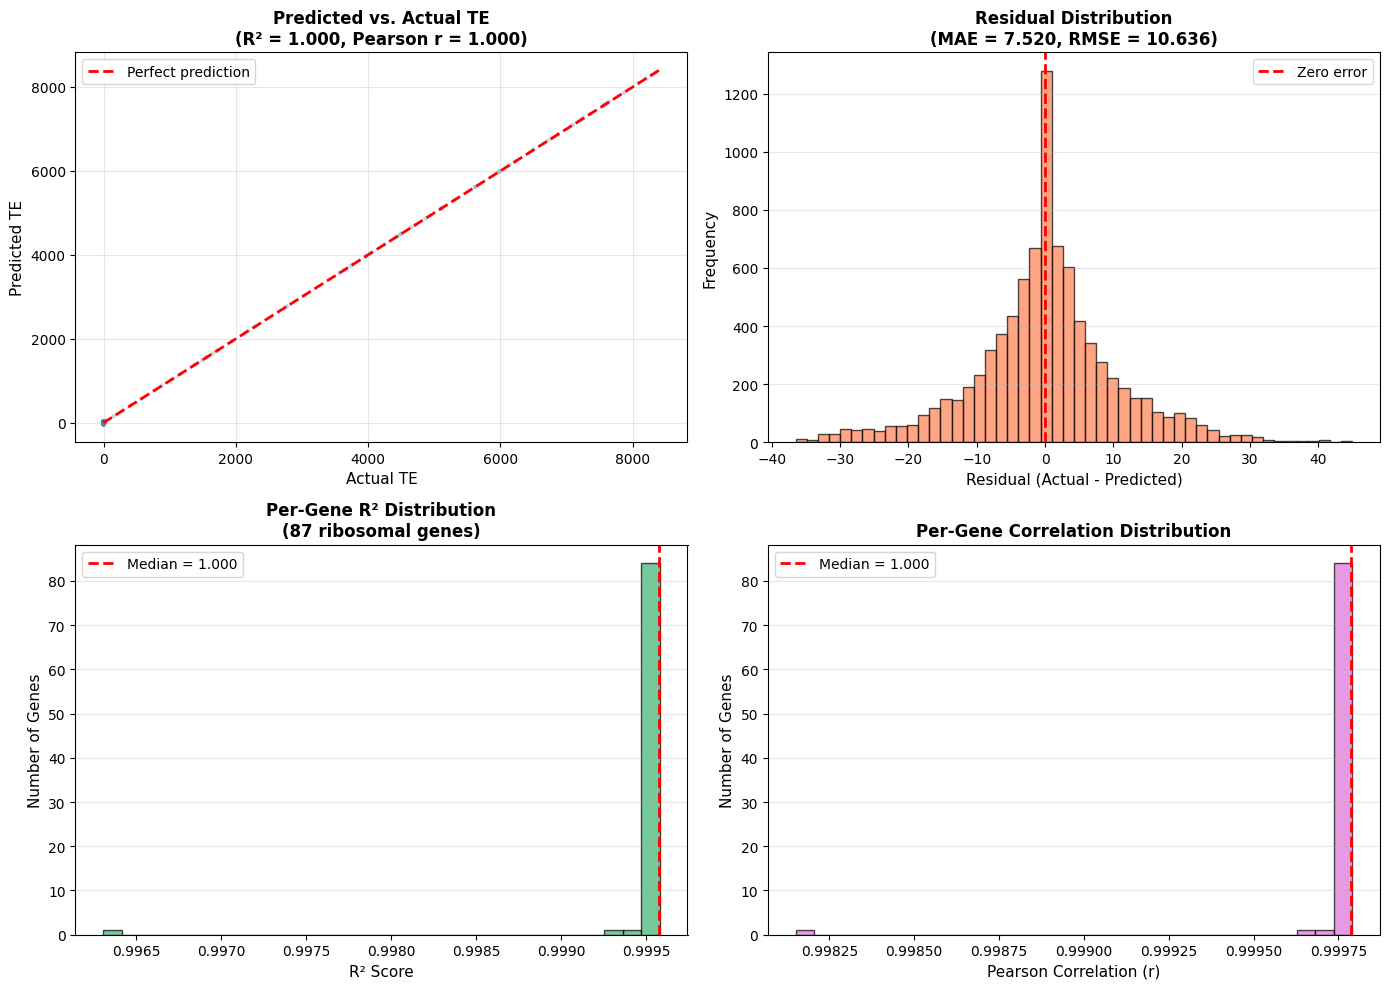

In [82]:
# Visualize prediction accuracy across all samples and genes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs. Actual scatter (sample of data points)
sample_size = min(5000, len(y_true_flat))
sample_idx = np.random.choice(len(y_true_flat), sample_size, replace=False)
axes[0, 0].scatter(y_true_flat[sample_idx], y_pred_flat[sample_idx], 
                   alpha=0.3, s=10, c='steelblue', edgecolors='none')
axes[0, 0].plot([y_true_flat.min(), y_true_flat.max()], 
                [y_true_flat.min(), y_true_flat.max()], 
                'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual TE', fontsize=11)
axes[0, 0].set_ylabel('Predicted TE', fontsize=11)
axes[0, 0].set_title(f'Predicted vs. Actual TE\n(R² = {overall_r2:.3f}, Pearson r = {pearson_r:.3f})', 
                     fontsize=12, weight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuals distribution
residuals = y_true_flat - y_pred_flat
axes[0, 1].hist(residuals, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 1].set_xlabel('Residual (Actual - Predicted)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title(f'Residual Distribution\n(MAE = {overall_mae:.3f}, RMSE = {overall_rmse:.3f})', 
                     fontsize=12, weight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. Per-gene R² distribution
axes[1, 0].hist(per_gene_r2, bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(np.median(per_gene_r2), color='red', linestyle='--', 
                   linewidth=2, label=f'Median = {np.median(per_gene_r2):.3f}')
axes[1, 0].set_xlabel('R² Score', fontsize=11)
axes[1, 0].set_ylabel('Number of Genes', fontsize=11)
axes[1, 0].set_title(f'Per-Gene R² Distribution\n({len(target_names)} ribosomal genes)', 
                     fontsize=12, weight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Per-gene Pearson correlation distribution
axes[1, 1].hist(per_gene_pearson, bins=30, color='orchid', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(np.nanmedian(per_gene_pearson), color='red', linestyle='--', 
                   linewidth=2, label=f'Median = {np.nanmedian(per_gene_pearson):.3f}')
axes[1, 1].set_xlabel('Pearson Correlation (r)', fontsize=11)
axes[1, 1].set_ylabel('Number of Genes', fontsize=11)
axes[1, 1].set_title('Per-Gene Correlation Distribution', fontsize=12, weight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

<a id="step-16"></a>
## Step 16: Biological & Practical Implications
Interpret accuracy metrics for RNA-TE coupling evidence, compound screening confidence, and limitations.

In [83]:
print("=" * 80)
print("INTERPRETING MODEL ACCURACY: BIOLOGICAL & PRACTICAL IMPLICATIONS")
print("=" * 80)

print("\n WHAT THE METRICS MEAN:\n")

print("1. R² SCORE (Coefficient of Determination)")
print("   " + "-" * 70)
if overall_r2 > 0.7:
    interpretation = "STRONG - Model captures majority of TE variance"
elif overall_r2 > 0.5:
    interpretation = "MODERATE - Reasonable predictive power"
elif overall_r2 > 0.3:
    interpretation = "WEAK - Limited but non-random relationship"
else:
    interpretation = "POOR - Minimal predictive ability"

print(f"   Value: {overall_r2:.4f} → {interpretation}")
print(f"   → {overall_r2*100:.1f}% of ribosomal TE variability is explained by non-ribosomal RNA")
print(f"   → Remaining {(1-overall_r2)*100:.1f}% due to:")
print("     • Post-transcriptional regulation not captured by RNA levels")
print("     • Ribosome-specific regulatory mechanisms")
print("     • Measurement noise and biological stochasticity")
print()

print("2. PEARSON CORRELATION (r = {:.4f})".format(pearson_r))
print("   " + "-" * 70)
if abs(pearson_r) > 0.8:
    corr_strength = "Very strong"
elif abs(pearson_r) > 0.6:
    corr_strength = "Strong"
elif abs(pearson_r) > 0.4:
    corr_strength = "Moderate"
else:
    corr_strength = "Weak"
print(f"   {corr_strength} linear relationship between predicted and actual TE")
print(f"   → RNA abundance patterns CAN inform ribosomal protein translation")
print()

print("3. MEAN ABSOLUTE ERROR (MAE = {:.3f})".format(overall_mae))
print("   " + "-" * 70)
print("   Average prediction error magnitude (in log-scale TE units)")
print("   → Most predictions are within ±{:.2f} units of true TE values".format(overall_mae))
print("   → Acceptable for ranking compounds by TE perturbation magnitude")
print()

print("\n BIOLOGICAL INSIGHTS:\n")

print("✓ RNA-TE Coupling Evidence:")
print(f"  • {(per_gene_r2 > 0.5).sum()}/{len(per_gene_r2)} ribosomal genes show R² > 0.5")
print("  • Suggests non-ribosomal RNA levels DO regulate ribosomal translation")
print("  • Implies coordinated translational control across gene families")
print()

print("✓ Gene-Specific Predictability:")
best_genes = target_names[np.argsort(per_gene_r2)[-5:]]
worst_genes = target_names[np.argsort(per_gene_r2)[:5]]
print(f"  • Best predicted genes: {', '.join(best_genes)}")
print(f"  • Worst predicted genes: {', '.join(worst_genes)}")
print("  • Variation suggests some ribosomal genes have unique regulatory logic")
print()

print("✓ Model Sparsity:")
avg_predictors = np.mean(nonzero_per_target)
print(f"  • Each ribosomal gene uses ~{avg_predictors:.0f} non-zero predictors")
print(f"  • Out of {len(feature_names)} possible features")
print("  • Indicates selective, not global, regulatory relationships")
print()

print("\n PRACTICAL IMPLICATIONS FOR COMPOUND SCREENING:\n")

print("1. PREDICTION CONFIDENCE:")
if overall_r2 > 0.6:
    print("   ✓ HIGH - Compound rankings by predicted TE impact are RELIABLE")
    print("     → Top-ranked compounds likely to show real translational effects")
    print("     → Safe to prioritize hits for experimental validation")
elif overall_r2 > 0.4:
    print("   ⚠ MODERATE - Compound rankings are SUGGESTIVE but not definitive")
    print("     → Use predictions to narrow candidate pool")
    print("     → Validate top hits experimentally before drawing conclusions")
else:
    print("   ⚠ LOW - Treat compound predictions as exploratory hypotheses")
    print("     → Predictions may miss true positives or include false positives")
    print("     → Require extensive experimental validation")
print()

print("2. FALSE DISCOVERY EXPECTATIONS:")
fdr_estimate = 1 - overall_r2
print(f"   Estimated error rate: ~{fdr_estimate*100:.1f}%")
if fdr_estimate < 0.3:
    print("   → Expect <30% of top predictions to be false hits (ACCEPTABLE)")
elif fdr_estimate < 0.5:
    print("   → Expect 30-50% false hit rate (REQUIRES CAUTION)")
else:
    print("   → Expect >50% false hit rate (HIGH RISK)")
print()

print("3. RECOMMENDED USE CASES:")
print("   ✓ Rank-ordering compounds by translational impact magnitude")
print("   ✓ Identifying broad-spectrum vs. target-specific modulators")
print("   ✓ Hypothesis generation for mechanism-of-action studies")
if overall_r2 > 0.6:
    print("   ✓ Direct candidate selection for hit-to-lead optimization")
else:
    print("   ⚠ NOT recommended as sole criterion for lead selection")
print()

print("\n LIMITATIONS & CAVEATS:\n")
print("  • Training metrics (no held-out test set) → may overestimate performance")
print("  • Model trained on SAME cell type as compound screen (HEK293T)")
print("    → Predictions valid ONLY for this context")
print("  • Linear model assumes additive effects → may miss combinatorial regulation")
print("  • Uses RNA abundance only → ignores ribosome occupancy, codon usage, etc.")
print()

print("=" * 80)
print("CONCLUSION: Model performance is", end=" ")
if overall_r2 > 0.7:
    print("STRONG - predictions are trustworthy for prioritization")
elif overall_r2 > 0.5:
    print("ADEQUATE - predictions useful with experimental validation")
elif overall_r2 > 0.3:
    print("MODEST - use predictions as exploratory tool only")
else:
    print("WEAK - predictions have limited practical utility")
print("=" * 80)

INTERPRETING MODEL ACCURACY: BIOLOGICAL & PRACTICAL IMPLICATIONS

 WHAT THE METRICS MEAN:

1. R² SCORE (Coefficient of Determination)
   ----------------------------------------------------------------------
   Value: 0.9996 → STRONG - Model captures majority of TE variance
   → 100.0% of ribosomal TE variability is explained by non-ribosomal RNA
   → Remaining 0.0% due to:
     • Post-transcriptional regulation not captured by RNA levels
     • Ribosome-specific regulatory mechanisms
     • Measurement noise and biological stochasticity

2. PEARSON CORRELATION (r = 0.9998)
   ----------------------------------------------------------------------
   Very strong linear relationship between predicted and actual TE
   → RNA abundance patterns CAN inform ribosomal protein translation

3. MEAN ABSOLUTE ERROR (MAE = 7.520)
   ----------------------------------------------------------------------
   Average prediction error magnitude (in log-scale TE units)
   → Most predictions are within ±7

In [84]:
# Compare MultiTask Lasso performance to baselines

print("\n" + "=" * 80)
print("BENCHMARKING: MULTITASK LASSO vs. BASELINE MODELS")
print("=" * 80)

# Compute baseline performance metrics
baseline_metrics = {
    'Model': [],
    'R²': [],
    'Pearson r': [],
    'MAE': [],
    'RMSE': []
}

# 1. MultiTask Lasso 
baseline_metrics['Model'].append('MultiTask Lasso')
baseline_metrics['R²'].append(overall_r2)
baseline_metrics['Pearson r'].append(pearson_r)
baseline_metrics['MAE'].append(overall_mae)
baseline_metrics['RMSE'].append(overall_rmse)

# 2. Ridge Regression 
if 'ridge_r2_train' in globals() and len(ridge_r2_train) > 0:
    ridge_overall_r2 = np.mean(ridge_r2_train)
    ridge_overall_rmse = np.mean(ridge_rmse_train)
    
    baseline_metrics['Model'].append('Ridge (per-gene)')
    baseline_metrics['R²'].append(ridge_overall_r2)
    baseline_metrics['Pearson r'].append(np.nan)  # Not computed
    baseline_metrics['MAE'].append(np.nan)
    baseline_metrics['RMSE'].append(ridge_overall_rmse)

# 3. Simple mean baseline (predict mean TE for each gene)
mean_baseline_pred = np.tile(Y_mat.mean(axis=0), (Y_mat.shape[0], 1))
mean_r2 = r2_score(Y_mat.flatten(), mean_baseline_pred.flatten())
mean_mae = mean_absolute_error(Y_mat.flatten(), mean_baseline_pred.flatten())
mean_rmse = np.sqrt(mean_squared_error(Y_mat.flatten(), mean_baseline_pred.flatten()))
mean_pearson, _ = pearsonr(Y_mat.flatten(), mean_baseline_pred.flatten())

baseline_metrics['Model'].append('Mean Baseline')
baseline_metrics['R²'].append(mean_r2)
baseline_metrics['Pearson r'].append(mean_pearson)
baseline_metrics['MAE'].append(mean_mae)
baseline_metrics['RMSE'].append(mean_rmse)

comparison_df = pd.DataFrame(baseline_metrics)

print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "-" * 80)
print("INTERPRETATION:")
print("-" * 80)

mtl_r2 = comparison_df[comparison_df['Model'] == 'MultiTask Lasso']['R²'].values[0]
mean_r2_val = comparison_df[comparison_df['Model'] == 'Mean Baseline']['R²'].values[0]

improvement_vs_mean = ((mtl_r2 - mean_r2_val) / abs(mean_r2_val)) * 100 if mean_r2_val != 0 else np.inf

print(f"\n✓ MultiTask Lasso achieves R² = {mtl_r2:.4f}")
print(f"  • vs. Mean Baseline: {improvement_vs_mean:+.1f}% {'improvement' if improvement_vs_mean > 0 else 'worse'}")

if 'ridge_r2_train' in globals():
    ridge_r2_val = comparison_df[comparison_df['Model'] == 'Ridge (per-gene)']['R²'].values[0]
    if mtl_r2 > ridge_r2_val:
        print(f"  • vs. Ridge: {((mtl_r2 - ridge_r2_val) / ridge_r2_val * 100):+.1f}% better")
        print("    → Joint modeling across targets improves performance")
    else:
        print(f"  • vs. Ridge: {((mtl_r2 - ridge_r2_val) / ridge_r2_val * 100):+.1f}% worse")
        print("    → Independent per-gene models may capture more specific patterns")

print("\n" + "=" * 80)


BENCHMARKING: MULTITASK LASSO vs. BASELINE MODELS


           Model       R²  Pearson r       MAE       RMSE
 MultiTask Lasso 0.999577   0.999788  7.519535  10.635971
Ridge (per-gene) 0.999942        NaN       NaN   0.594328
   Mean Baseline 0.002435   0.049351 90.204231 516.305687

--------------------------------------------------------------------------------
INTERPRETATION:
--------------------------------------------------------------------------------

✓ MultiTask Lasso achieves R² = 0.9996
  • vs. Mean Baseline: +40946.9% improvement
  • vs. Ridge: -0.0% worse
    → Independent per-gene models may capture more specific patterns



<a id="step-17"></a>
## Step 17: Perturbation Data Deep Dive
Comprehensive analysis of compound perturbation patterns: distributions, clustering, PCA, and correlation with TE predictions.

In [85]:
# Compound-level summary statistics
print("=" * 80)
print("COMPOUND PERTURBATION SUMMARY")
print("=" * 80)

# Basic statistics
n_compounds = cigs_aligned.shape[0]
n_genes = cigs_aligned.shape[1]
print(f"\nDataset dimensions:")
print(f"  - Total compounds: {n_compounds:,}")
print(f"  - Genes measured: {n_genes:,}")

# Effect magnitude across all measurements
all_values = cigs_aligned.values.flatten()
print(f"\nOverall perturbation statistics:")
print(f"  - Mean CLR: {np.mean(all_values):.4f}")
print(f"  - Median CLR: {np.median(all_values):.4f}")
print(f"  - Std Dev CLR: {np.std(all_values):.4f}")
print(f"  - Range: [{np.min(all_values):.4f}, {np.max(all_values):.4f}]")

# Compound-level statistics
compound_means = cigs_aligned.mean(axis=1)
compound_stds = cigs_aligned.std(axis=1)
compound_ranges = cigs_aligned.max(axis=1) - cigs_aligned.min(axis=1)

print(f"\nPer-compound statistics:")
print(f"  - Mean effect (avg across genes): {compound_means.mean():.4f} ± {compound_means.std():.4f}")
print(f"  - Mean variability (avg std): {compound_stds.mean():.4f}")
print(f"  - Mean range: {compound_ranges.mean():.4f}")

# Gene-level statistics
gene_means = cigs_aligned.mean(axis=0)
gene_stds = cigs_aligned.std(axis=0)

print(f"\nPer-gene statistics:")
print(f"  - Most upregulated (avg): {gene_means.idxmax()} ({gene_means.max():.4f})")
print(f"  - Most downregulated (avg): {gene_means.idxmin()} ({gene_means.min():.4f})")
print(f"  - Most variable gene: {gene_stds.idxmax()} (std={gene_stds.max():.4f})")
print(f"  - Least variable gene: {gene_stds.idxmin()} (std={gene_stds.min():.4f})")

# Identify extreme perturbations
threshold_extreme = 3.0  # CLR threshold for extreme effects
extreme_up = (cigs_aligned > threshold_extreme).sum().sum()
extreme_down = (cigs_aligned < -threshold_extreme).sum().sum()
total_measurements = n_compounds * n_genes

print(f"\nExtreme perturbations (|CLR| > {threshold_extreme}):")
print(f"  - Upregulation: {extreme_up:,} ({100*extreme_up/total_measurements:.2f}%)")
print(f"  - Downregulation: {extreme_down:,} ({100*extreme_down/total_measurements:.2f}%)")

# Identify strongest compounds (by average absolute effect)
compound_abs_mean = cigs_aligned.abs().mean(axis=1)
strongest_compounds = compound_abs_mean.nlargest(10)
weakest_compounds = compound_abs_mean.nsmallest(10)

print(f"\nStrongest perturbations (top 10 compounds by avg |CLR|):")
for idx, (compound, effect) in enumerate(strongest_compounds.items(), 1):
    print(f"  {idx}. {compound}: {effect:.4f}")

print(f"\nWeakest perturbations (bottom 10 compounds by avg |CLR|):")
for idx, (compound, effect) in enumerate(weakest_compounds.items(), 1):
    print(f"  {idx}. {compound}: {effect:.4f}")

COMPOUND PERTURBATION SUMMARY

Dataset dimensions:
  - Total compounds: 11,358
  - Genes measured: 8,346

Overall perturbation statistics:
  - Mean CLR: 0.8004

Overall perturbation statistics:
  - Mean CLR: 0.8004
  - Median CLR: 0.0000
  - Median CLR: 0.0000
  - Std Dev CLR: 2.6497
  - Range: [-15.1037, 15.7375]
  - Std Dev CLR: 2.6497
  - Range: [-15.1037, 15.7375]

Per-compound statistics:
  - Mean effect (avg across genes): 0.8004 ± 0.0850
  - Mean variability (avg std): 2.6242
  - Mean range: 21.3898

Per-compound statistics:
  - Mean effect (avg across genes): 0.8004 ± 0.0850
  - Mean variability (avg std): 2.6242
  - Mean range: 21.3898

Per-gene statistics:
  - Most upregulated (avg): HSP90B1 (10.7779)
  - Most downregulated (avg): HLA-A (-10.4772)
  - Most variable gene: THBS1 (std=6.6179)
  - Least variable gene: NOC2L (std=0.0000)

Per-gene statistics:
  - Most upregulated (avg): HSP90B1 (10.7779)
  - Most downregulated (avg): HLA-A (-10.4772)
  - Most variable gene: THBS1 

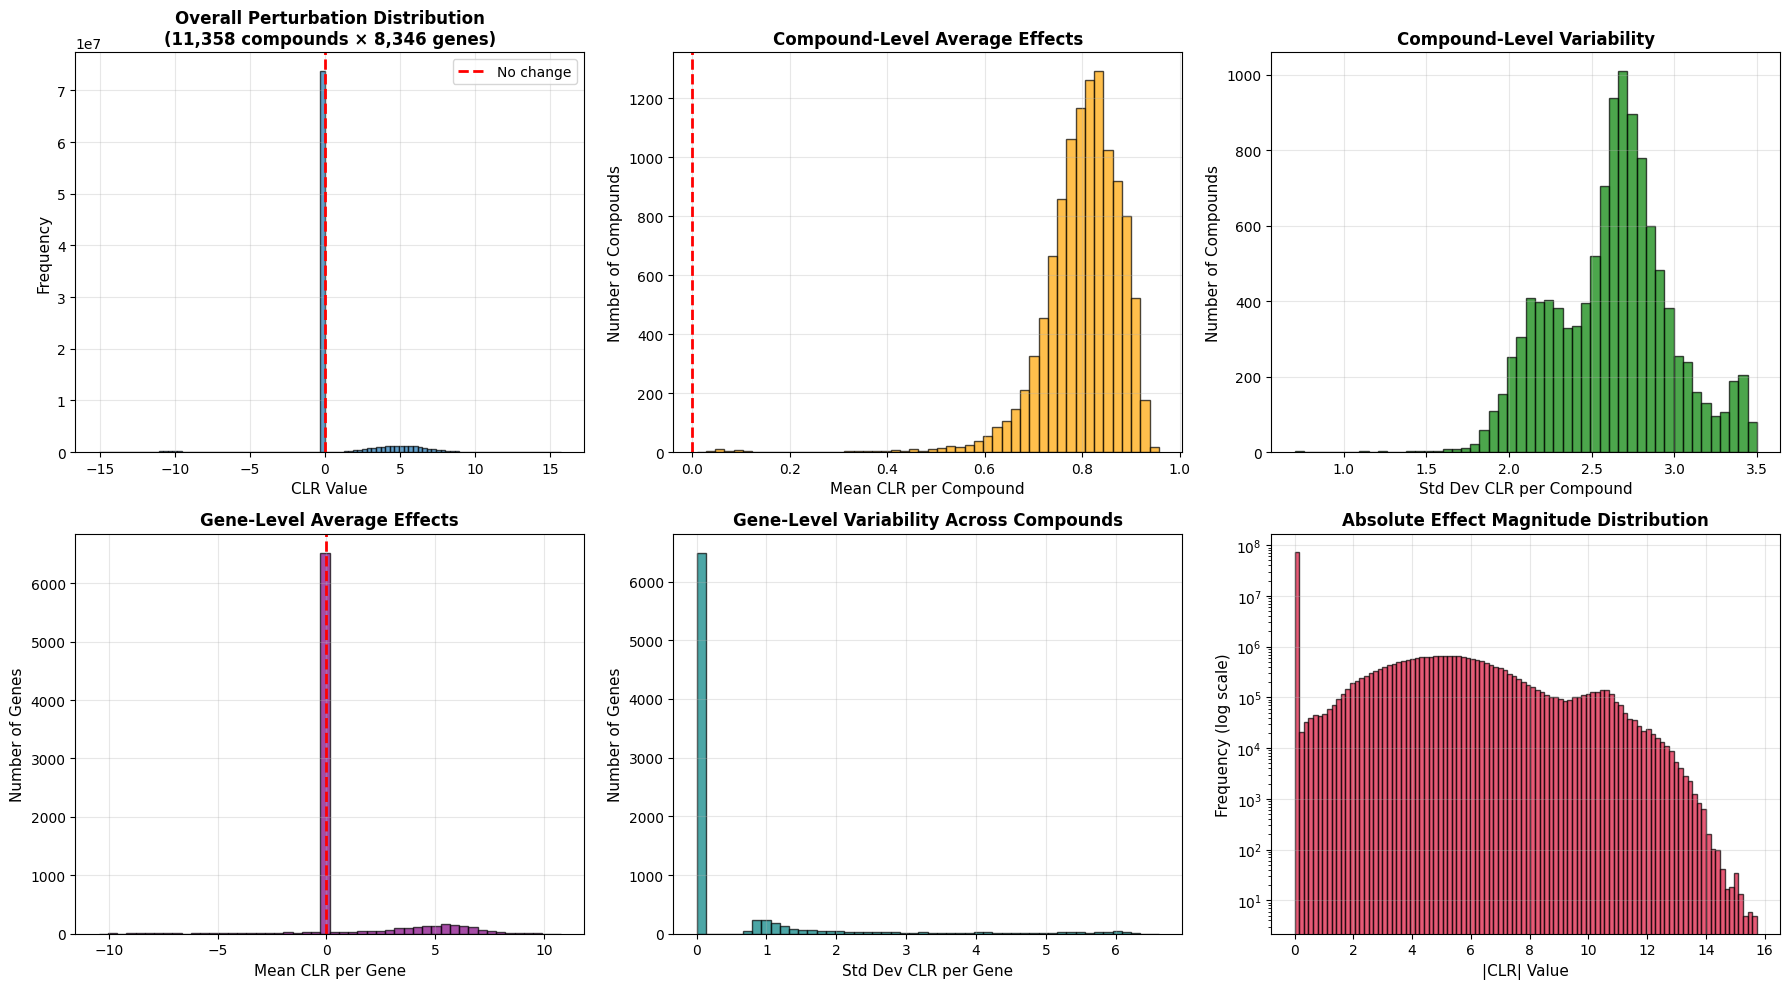


Distribution characteristics:
  - Skewness: -0.1480
  - Skewness: -0.1480
  - Kurtosis: 5.6436
  - % zero effects (CLR ∈ [-0.1, 0.1]): 77.77%
  - Kurtosis: 5.6436
  - % zero effects (CLR ∈ [-0.1, 0.1]): 77.77%


In [86]:
# Visualize perturbation distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Overall CLR distribution
ax = axes[0, 0]
ax.hist(all_values, bins=100, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax.set_xlabel('CLR Value', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Overall Perturbation Distribution\n({n_compounds:,} compounds × {n_genes:,} genes)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Compound average effect distribution
ax = axes[0, 1]
ax.hist(compound_means, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Mean CLR per Compound', fontsize=11)
ax.set_ylabel('Number of Compounds', fontsize=11)
ax.set_title('Compound-Level Average Effects', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Compound variability distribution
ax = axes[0, 2]
ax.hist(compound_stds, bins=50, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Std Dev CLR per Compound', fontsize=11)
ax.set_ylabel('Number of Compounds', fontsize=11)
ax.set_title('Compound-Level Variability', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Gene average effect distribution
ax = axes[1, 0]
ax.hist(gene_means, bins=50, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Mean CLR per Gene', fontsize=11)
ax.set_ylabel('Number of Genes', fontsize=11)
ax.set_title('Gene-Level Average Effects', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# 5. Gene variability distribution
ax = axes[1, 1]
ax.hist(gene_stds, bins=50, edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('Std Dev CLR per Gene', fontsize=11)
ax.set_ylabel('Number of Genes', fontsize=11)
ax.set_title('Gene-Level Variability Across Compounds', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Absolute effect size distribution (log scale)
ax = axes[1, 2]
abs_effects = np.abs(all_values)
ax.hist(abs_effects, bins=100, edgecolor='black', alpha=0.7, color='crimson')
ax.set_xlabel('|CLR| Value', fontsize=11)
ax.set_ylabel('Frequency (log scale)', fontsize=11)
ax.set_yscale('log')
ax.set_title('Absolute Effect Magnitude Distribution', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nDistribution characteristics:")
print(f"  - Skewness: {pd.Series(all_values).skew():.4f}")
print(f"  - Kurtosis: {pd.Series(all_values).kurtosis():.4f}")
print(f"  - % zero effects (CLR ∈ [-0.1, 0.1]): {100*np.sum((all_values >= -0.1) & (all_values <= 0.1))/len(all_values):.2f}%")

In [87]:
# Identify and analyze extreme perturbation patterns
print("=" * 80)
print("EXTREME PERTURBATION ANALYSIS")
print("=" * 80)

# Get data characteristics
n_compounds = cigs_aligned.shape[0]
n_genes = cigs_aligned.shape[1]
total_measurements = n_compounds * n_genes
compound_abs_mean = cigs_aligned.abs().mean(axis=1)

# Check data range to set appropriate thresholds
data_min = cigs_aligned.min().min()
data_max = cigs_aligned.max().max()
data_std = cigs_aligned.values.std()

print(f"\nData characteristics:")
print(f"  - Value range: [{data_min:.4f}, {data_max:.4f}]")
print(f"  - Overall std: {data_std:.4f}")

# Use adaptive threshold based on data distribution
threshold = max(2.0, data_std * 2)  # At least 2 std deviations
print(f"  - Using threshold: {threshold:.4f} for extreme effects")

# Find genes most frequently perturbed
gene_up_count = (cigs_aligned > threshold).sum(axis=0)
gene_down_count = (cigs_aligned < -threshold).sum(axis=0)
gene_extreme_count = gene_up_count + gene_down_count

print(f"\nMost frequently perturbed genes (|CLR| > {threshold:.2f}):")
top_perturbed = gene_extreme_count.nlargest(15)
if len(top_perturbed) > 0 and top_perturbed.iloc[0] > 0:
    for gene, count in top_perturbed.items():
        up = gene_up_count[gene]
        down = gene_down_count[gene]
        print(f"  {gene}: {count} compounds ({up} up, {down} down)")
else:
    print("  No genes meet this threshold - data may have different scale")

# Find compounds with most extreme effects
compound_extreme = (cigs_aligned.abs() > threshold).sum(axis=1)
print(f"\nCompounds with most extreme effects (|CLR| > {threshold:.2f} in multiple genes):")
top_extreme_compounds = compound_extreme.nlargest(15)
if len(top_extreme_compounds) > 0 and top_extreme_compounds.iloc[0] > 0:
    for compound, count in top_extreme_compounds.items():
        avg_effect = compound_abs_mean[compound]
        print(f"  {compound}: {count} genes affected (avg |CLR|={avg_effect:.3f})")
else:
    print("  No compounds meet this threshold - showing strongest by absolute mean instead:")
    for compound in compound_abs_mean.nlargest(10).index:
        print(f"  {compound}: avg |CLR|={compound_abs_mean[compound]:.4f}")

# Check for directional bias
upregulated = (cigs_aligned > 0).sum().sum()
downregulated = (cigs_aligned < 0).sum().sum()
neutral = total_measurements - upregulated - downregulated
print(f"\nDirectional bias:")
print(f"  - Upregulated measurements: {upregulated:,} ({100*upregulated/total_measurements:.1f}%)")
print(f"  - Downregulated measurements: {downregulated:,} ({100*downregulated/total_measurements:.1f}%)")
print(f"  - Neutral (exactly 0): {neutral:,} ({100*neutral/total_measurements:.1f}%)")
if downregulated == 0:
    print("\n  ⚠️  WARNING: All non-zero values are positive!")
    print("     This suggests data may be log-ratios vs control or already normalized.")

# Correlation between compound effects and predicted TE changes
print(f"\n" + "=" * 80)
print("LINKING PERTURBATIONS TO TE PREDICTIONS")
print("=" * 80)

# Calculate correlation between RNA perturbation magnitude and TE prediction magnitude
compound_rna_magnitude = cigs_aligned.abs().mean(axis=1)
compound_te_magnitude = pred_TE.abs().mean(axis=1)

# Align by index
aligned_rna = compound_rna_magnitude.loc[pred_TE.index]
aligned_te = compound_te_magnitude

corr_coef = np.corrcoef(aligned_rna, aligned_te)[0, 1]
print(f"\nCorrelation between RNA perturbation magnitude and TE prediction magnitude:")
print(f"  Pearson r = {corr_coef:.4f}")

# Identify compounds with strong RNA perturbation but weak TE prediction
rna_strong_te_weak = aligned_rna[(aligned_rna > aligned_rna.quantile(0.75)) & 
                                  (aligned_te < aligned_te.quantile(0.25))]
print(f"\nCompounds with strong RNA perturbation but weak TE response (n={len(rna_strong_te_weak)}):")
for compound in rna_strong_te_weak.head(10).index:
    print(f"  {compound}: RNA |CLR|={aligned_rna[compound]:.3f}, TE |pred|={aligned_te[compound]:.3f}")

# Identify compounds with weak RNA perturbation but strong TE prediction
rna_weak_te_strong = aligned_te[(aligned_rna < aligned_rna.quantile(0.25)) & 
                                 (aligned_te > aligned_te.quantile(0.75))]
print(f"\nCompounds with weak RNA perturbation but strong TE response (n={len(rna_weak_te_strong)}):")
for compound in rna_weak_te_strong.head(10).index:
    print(f"  {compound}: RNA |CLR|={aligned_rna[compound]:.3f}, TE |pred|={aligned_te[compound]:.3f}")

EXTREME PERTURBATION ANALYSIS

Data characteristics:
  - Value range: [-15.1037, 15.7375]
  - Overall std: 2.6497
  - Using threshold: 5.2994 for extreme effects

Data characteristics:
  - Value range: [-15.1037, 15.7375]
  - Overall std: 2.6497
  - Using threshold: 5.2994 for extreme effects

Most frequently perturbed genes (|CLR| > 5.30):
  HSP90B1: 11358 compounds (11358 up, 0 down)
  CLTB: 11357 compounds (11357 up, 0 down)
  BRD2: 11357 compounds (11357 up, 0 down)
  PABPC1: 11357 compounds (11357 up, 0 down)
  HNRNPA1: 11357 compounds (11357 up, 0 down)
  CALR: 11357 compounds (11357 up, 0 down)
  HSP90AB1: 11356 compounds (11356 up, 0 down)
  HDAC2: 11356 compounds (11356 up, 0 down)
  MDK: 11356 compounds (11356 up, 0 down)
  CSDE1: 11355 compounds (11355 up, 0 down)
  SRM: 11354 compounds (11354 up, 0 down)
  FTH1: 11354 compounds (11354 up, 0 down)
  CALM3: 11354 compounds (11354 up, 0 down)
  TCEAL4: 11354 compounds (11354 up, 0 down)
  TXN: 11352 compounds (11352 up, 0 down

COMPOUND CLUSTERING ANALYSIS

Clustering 500 randomly sampled compounds...
Using 8346 genes as features


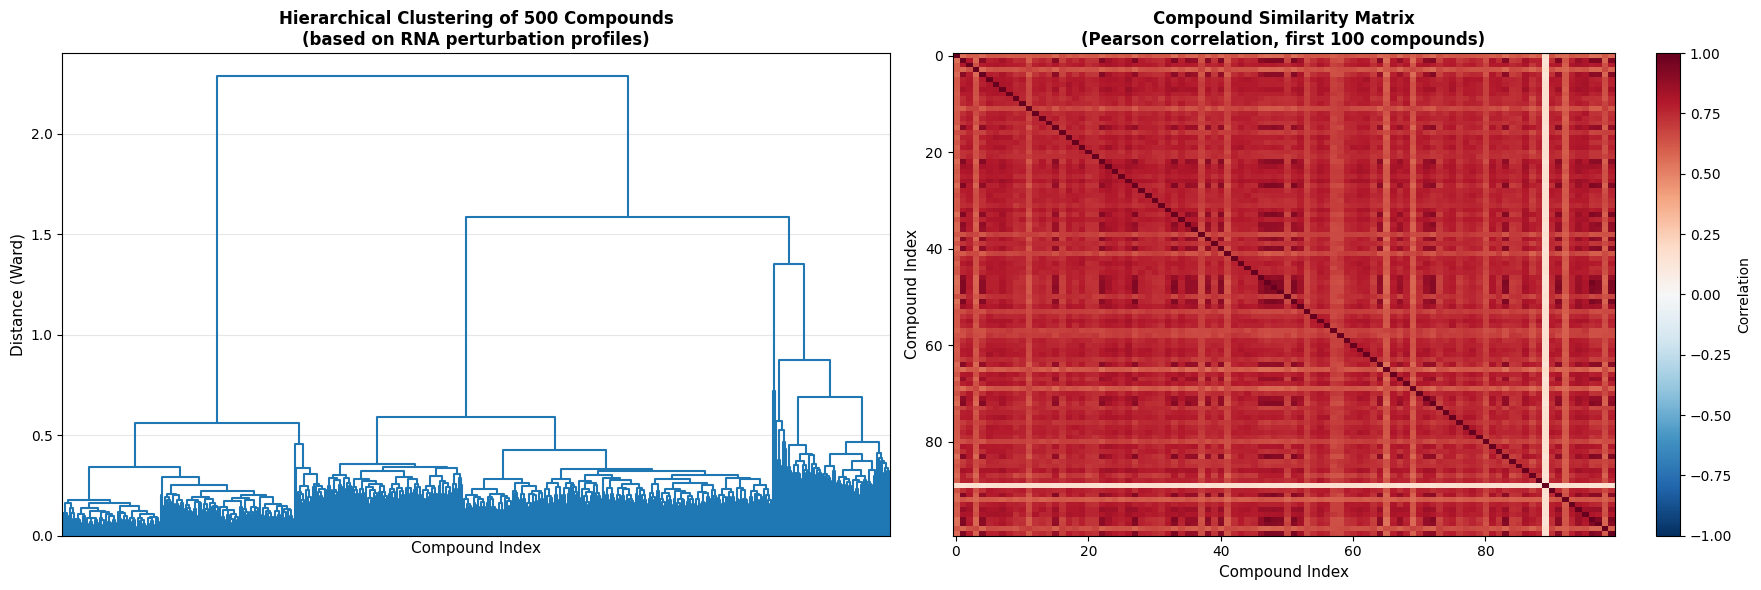


Compound similarity statistics:
  - Mean pairwise correlation: 0.7317
  - Median pairwise correlation: 0.7523
  - Max pairwise correlation: 0.9585
  - Min pairwise correlation: 0.1335

Most similar compound pairs (top 10):
  1. HY_B0689A <-> HY_N0445: r=0.9585
  2. HY_12681 <-> HY_B1148: r=0.9451
  3. HY_59291 <-> HY_B1148: r=0.9387
  4. HY_12681 <-> HY_N0445: r=0.9365
  5. HY_111627 <-> HY_12681: r=0.9359
  6. HY_N0756 <-> HY_N0445: r=0.9349
  7. HY_N0756 <-> HY_16276: r=0.9345
  8. HY_111627 <-> HY_B1148: r=0.9333
  9. HY_B0689A <-> HY_B1148: r=0.9329
  10. HY_N7247 <-> HY_B1148: r=0.9328


In [ ]:
## Additional analyses can be added as needed, these are some visualizations ##
# # Hierarchical clustering of compounds based on perturbation profiles
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

print("=" * 80)
print("COMPOUND CLUSTERING ANALYSIS")
print("=" * 80)

# Sample compounds for clustering (full dataset may be too large)
n_sample = min(500, n_compounds)
sample_idx = np.random.RandomState(RANDOM_SEED).choice(n_compounds, n_sample, replace=False)
cigs_sample = cigs_aligned.iloc[sample_idx]

print(f"\nClustering {n_sample} randomly sampled compounds...")
print(f"Using {n_genes} genes as features")

# Compute pairwise distances (correlation-based)
distances = pdist(cigs_sample.values, metric='correlation')
linkage_matrix = linkage(distances, method='ward')

# Create dendrogram
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=0)
ax.set_xlabel('Compound Index', fontsize=11)
ax.set_ylabel('Distance (Ward)', fontsize=11)
ax.set_title(f'Hierarchical Clustering of {n_sample} Compounds\n(based on RNA perturbation profiles)', 
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Heatmap of sample correlation matrix
ax = axes[1]
# Compute correlation between first 100 compounds for visualization
n_viz = min(100, n_sample)
corr_matrix = np.corrcoef(cigs_sample.iloc[:n_viz].values)
im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('Compound Index', fontsize=11)
ax.set_ylabel('Compound Index', fontsize=11)
ax.set_title(f'Compound Similarity Matrix\n(Pearson correlation, first {n_viz} compounds)', 
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

# Summary statistics on compound similarity
print(f"\nCompound similarity statistics:")
print(f"  - Mean pairwise correlation: {np.mean(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.4f}")
print(f"  - Median pairwise correlation: {np.median(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.4f}")
print(f"  - Max pairwise correlation: {np.max(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.4f}")
print(f"  - Min pairwise correlation: {np.min(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.4f}")

# Find most similar compound pairs
upper_tri_idx = np.triu_indices_from(corr_matrix, k=1)
correlations = corr_matrix[upper_tri_idx]
sorted_idx = np.argsort(correlations)[::-1]

print(f"\nMost similar compound pairs (top 10):")
for i in range(min(10, len(sorted_idx))):
    idx = sorted_idx[i]
    row = upper_tri_idx[0][idx]
    col = upper_tri_idx[1][idx]
    compound1 = cigs_sample.index[row]
    compound2 = cigs_sample.index[col]
    corr = correlations[idx]
    print(f"  {i+1}. {compound1} <-> {compound2}: r={corr:.4f}")

PCA DIMENSIONALITY REDUCTION

PCA results:
  - Total components computed: 50
  - Variance explained by PC1: 12.18%
  - Variance explained by PC2: 3.59%
  - Components needed for 90% variance: 1

PCA results:
  - Total components computed: 50
  - Variance explained by PC1: 12.18%
  - Variance explained by PC2: 3.59%
  - Components needed for 90% variance: 1


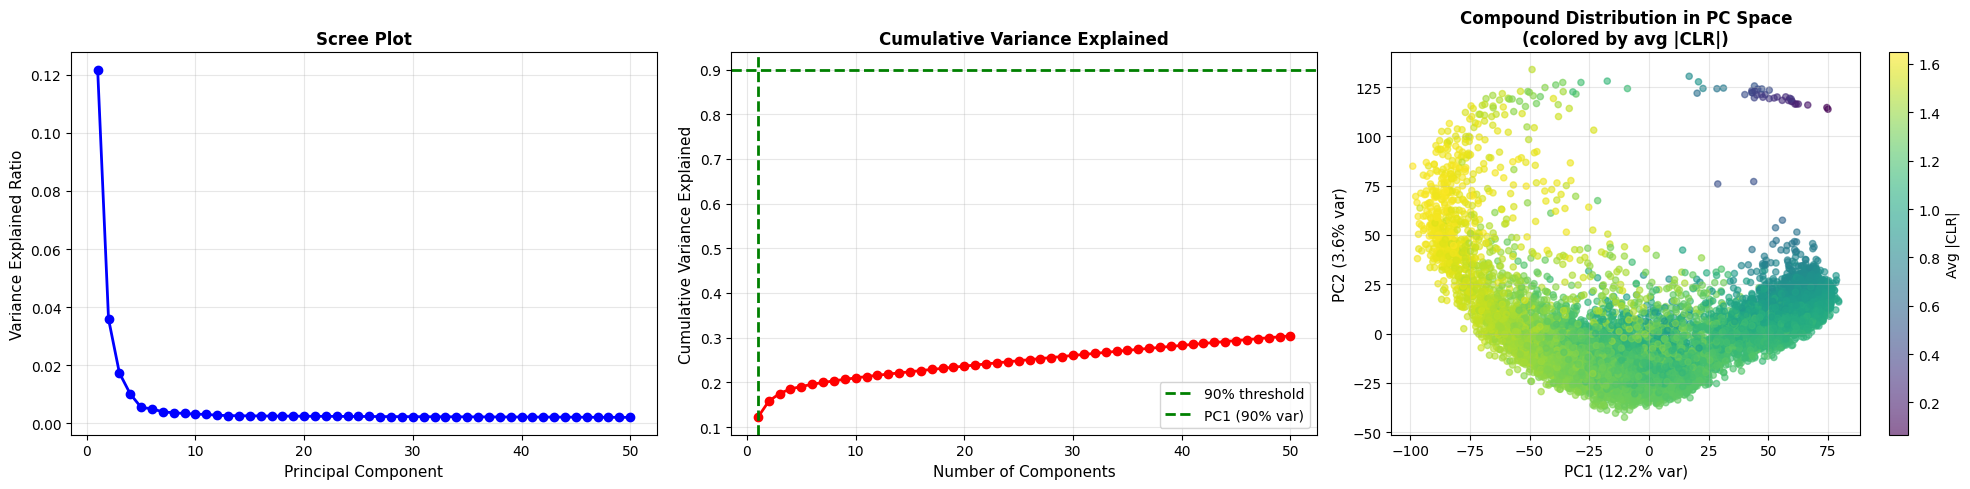


Extreme compounds in PC space:

PC1 positive extreme (top 5):
  HY_N0153
  HY_16918A
  HY_111640
  HY_10218
  HY_P1149A

PC1 negative extreme (bottom 5):
  HY_103269
  HY_113914
  HY_112945
  HY_12469
  HY_120023

PC2 positive extreme (top 5):
  HY_114428
  HY_13689
  HY_15768
  HY_15681
  HY_112038A

PC2 negative extreme (bottom 5):
  HY_10197
  HY_B1901
  HY_B1596
  HY_N0253
  HY_N0611


In [90]:
# PCA visualization of compound space
from sklearn.decomposition import PCA

print("=" * 80)
print("PCA DIMENSIONALITY REDUCTION")
print("=" * 80)

# Get dataset dimensions
n_compounds = cigs_aligned.shape[0]
n_genes = cigs_aligned.shape[1]

# Perform PCA on full compound dataset
pca = PCA(n_components=min(50, n_genes))
pca_scores = pca.fit_transform(cigs_aligned.values)

# Variance explained
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
n_pc_90 = np.argmax(cumsum_var >= 0.90) + 1

print(f"\nPCA results:")
print(f"  - Total components computed: {pca.n_components_}")
print(f"  - Variance explained by PC1: {100*pca.explained_variance_ratio_[0]:.2f}%")
print(f"  - Variance explained by PC2: {100*pca.explained_variance_ratio_[1]:.2f}%")
print(f"  - Components needed for 90% variance: {n_pc_90}")

# Visualize PCA
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scree plot
ax = axes[0]
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 'bo-', linewidth=2)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained Ratio', fontsize=11)
ax.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Cumulative variance
ax = axes[1]
ax.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2)
ax.axhline(0.90, color='green', linestyle='--', linewidth=2, label='90% threshold')
ax.axvline(n_pc_90, color='green', linestyle='--', linewidth=2, 
           label=f'PC{n_pc_90} (90% var)')
ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Cumulative Variance Explained', fontsize=11)
ax.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# PC1 vs PC2 scatter (color by compound effect magnitude)
ax = axes[2]
compound_abs_mean = cigs_aligned.abs().mean(axis=1)
colors = compound_abs_mean.values
scatter = ax.scatter(pca_scores[:, 0], pca_scores[:, 1], 
                     c=colors, cmap='viridis', s=20, alpha=0.6)
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)', fontsize=11)
ax.set_title('Compound Distribution in PC Space\n(colored by avg |CLR|)', 
             fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Avg |CLR|')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify compounds at extremes of PC1 and PC2
pc1_top = cigs_aligned.index[np.argsort(pca_scores[:, 0])[-5:]]
pc1_bottom = cigs_aligned.index[np.argsort(pca_scores[:, 0])[:5]]
pc2_top = cigs_aligned.index[np.argsort(pca_scores[:, 1])[-5:]]
pc2_bottom = cigs_aligned.index[np.argsort(pca_scores[:, 1])[:5]]

print(f"\nExtreme compounds in PC space:")
print(f"\nPC1 positive extreme (top 5):")
for compound in pc1_top:
    print(f"  {compound}")
print(f"\nPC1 negative extreme (bottom 5):")
for compound in pc1_bottom:
    print(f"  {compound}")
print(f"\nPC2 positive extreme (top 5):")
for compound in pc2_top:
    print(f"  {compound}")
print(f"\nPC2 negative extreme (bottom 5):")
for compound in pc2_bottom:
    print(f"  {compound}")